In [4]:
import pandas as pd

In [5]:
df= pd.read_csv("input_data/Yeast_consolidated_gene_regulation_network.csv")

In [6]:
df.shape

(1120, 8)

In [7]:
# remove duplicate rows
df = df.drop_duplicates()
df.shape

(675, 8)

In [8]:
df.head()

,Reg,weight_1,weight_2,weight_3,weight_4,weight_5,weight_6,weight_7
0,YPR182W_YOL039W,0.010540,0.007368,0.0,0.0,0.0108,0.007423,0.007207
1,snR77_YBR252W,0.010698,0.000000,0.0,0.0,0.0000,0.000000,0.000000
2,snR77_YLR062C,0.011013,0.000000,0.0,0.0,0.0000,0.000000,0.000000
3,snR77_YGR063C,0.012532,0.000000,0.0,0.0,0.0000,0.000000,0.000000
4,snR77_YLR402W,0.040704,0.000000,0.0,0.0,0.0000,0.000000,0.029929


In [9]:
# count negative values
(df.iloc[:,1:] < 0).sum().sum()

np.int64(23)

In [10]:

# replace values with 0 if lower than 0.01
df[df.iloc[:,1:] < 0.01] = 0
df.head(83)

,Reg,weight_1,weight_2,weight_3,weight_4,weight_5,weight_6,weight_7
0,YPR182W_YOL039W,0.010540,0.0,0.000000,0.000000,0.0108,0.000000,0.000000
1,snR77_YBR252W,0.010698,0.0,0.000000,0.000000,0.0000,0.000000,0.000000
2,snR77_YLR062C,0.011013,0.0,0.000000,0.000000,0.0000,0.000000,0.000000
3,snR77_YGR063C,0.012532,0.0,0.000000,0.000000,0.0000,0.000000,0.000000
4,snR77_YLR402W,0.040704,0.0,0.000000,0.000000,0.0000,0.000000,0.029929
...,...,...,...,...,...,...,...,...
78,snR39_YDR185C,0.010948,0.0,0.000000,0.000000,0.0000,0.000000,0.000000
79,snR39_YJL118W,0.013294,0.0,0.000000,0.000000,0.0000,0.000000,0.000000
80,snR39_YNL028W,0.018541,0.0,0.000000,0.000000,0.0000,0.000000,0.000000
81,snR39_snR55,0.068143,0.0,0.042636,0.074284,0.0000,0.000000,0.000000


In [11]:
# set Reg column to be index
df = df.set_index('Reg')
df.head()

,weight_1,weight_2,weight_3,weight_4,weight_5,weight_6,weight_7
Reg,,,,,,,
YPR182W_YOL039W,0.010540,0.0,0.0,0.0,0.0108,0.0,0.000000
snR77_YBR252W,0.010698,0.0,0.0,0.0,0.0000,0.0,0.000000
snR77_YLR062C,0.011013,0.0,0.0,0.0,0.0000,0.0,0.000000
snR77_YGR063C,0.012532,0.0,0.0,0.0,0.0000,0.0,0.000000
snR77_YLR402W,0.040704,0.0,0.0,0.0,0.0000,0.0,0.029929


In [12]:
# create a new dataframe with Reg and patterns: ekspression in first 1 or 2 modules only, in middle only, in last only, always expressed, increasing od decreasing expr

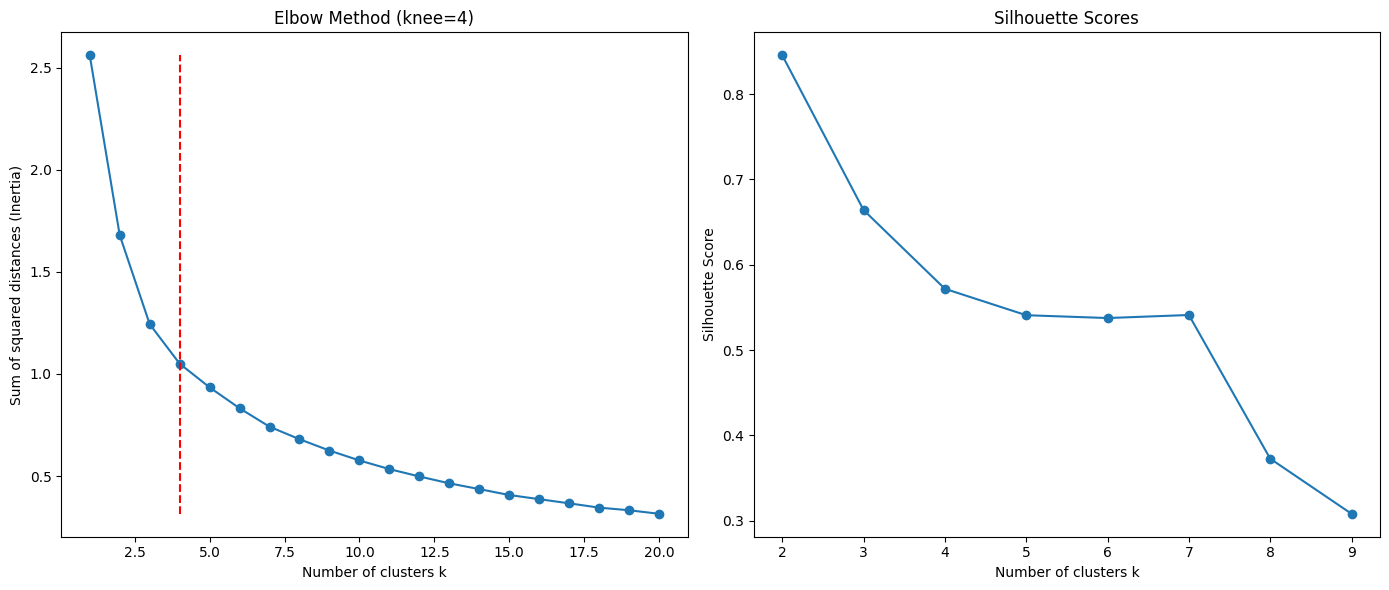

In [13]:
# kmeans clustering
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
from kneed import KneeLocator
from sklearn.metrics import silhouette_score



# -----------------------
# 3. Elbow method (Inertia)
# -----------------------
sse = []
k_range = range(1, 21)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=100)
    kmeans.fit(df)
    sse.append(kmeans.inertia_)

knee = KneeLocator(k_range, sse, curve='convex', direction='decreasing')

# -----------------------
# 4. Silhouette scores
# -----------------------
silhouette_scores = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=100)
    labels = kmeans.fit_predict(df)
    score = silhouette_score(df, labels)
    silhouette_scores.append(score)

# -----------------------
# 5. Plot both side by side
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Elbow plot
axes[0].plot(k_range, sse, marker='o')
if knee.knee is not None:
    axes[0].vlines(knee.knee, ymin=min(sse), ymax=max(sse), colors='r', linestyles='dashed')
    axes[0].set_title(f'Elbow Method (knee={knee.knee})')
else:
    axes[0].set_title("Elbow Method (no clear knee)")
axes[0].set_xlabel('Number of clusters k')
axes[0].set_ylabel('Sum of squared distances (Inertia)')

# Silhouette plot
axes[1].plot(range(2, 10), silhouette_scores, marker='o')
axes[1].set_title("Silhouette Scores")
axes[1].set_xlabel('Number of clusters k')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()


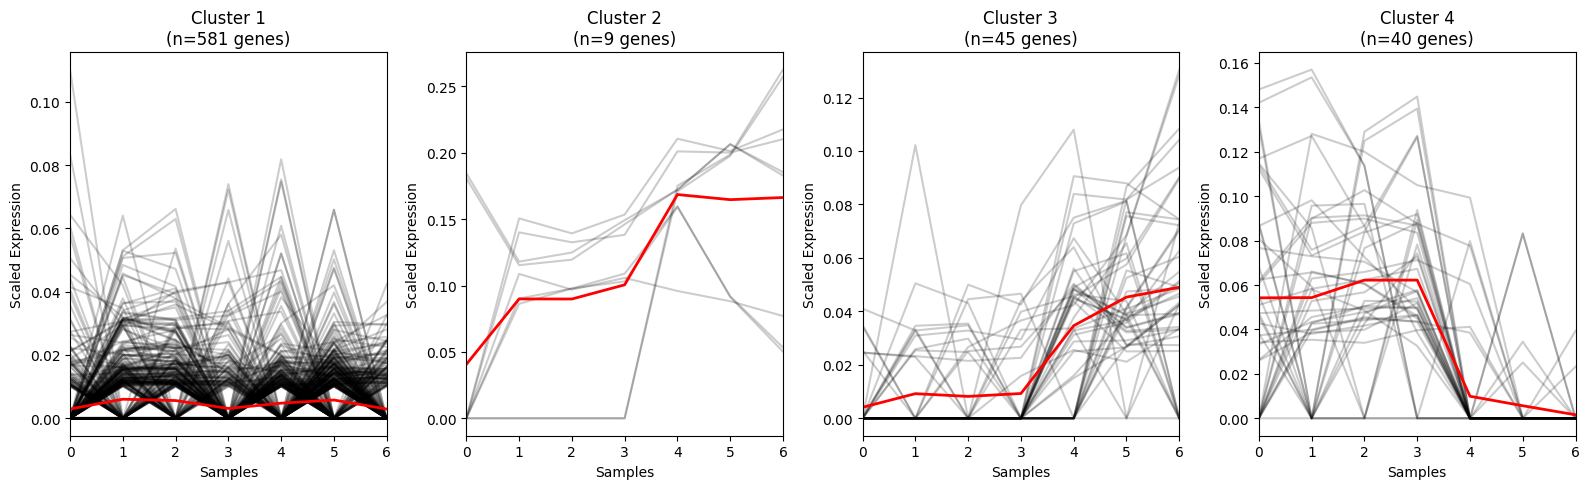

Silhouette Score for k=4: 0.5717


In [14]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

# -----------------------
# 1. KMeans clustering
# -----------------------
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=100)
labels = kmeans.fit_predict(df)

# Add cluster labels to the DataFrame
df['cluster'] = labels

# -----------------------
# 2. Plot clusters side by side
# -----------------------
plt.figure(figsize=(4 * n_clusters, 5))  # width scales with number of clusters

for cluster in range(n_clusters):
    cluster_data = df[df['cluster'] == cluster].drop(columns='cluster')
    
    plt.subplot(1, n_clusters, cluster + 1)
    
    # Plot all genes in black
    for index, row in cluster_data.iterrows():
        plt.plot(row.values, color='black', alpha=0.2)
    
    # Plot mean profile in red
    mean_profile = cluster_data.mean(axis=0)
    plt.plot(mean_profile.values, color='red', linewidth=2)
    
    plt.title(f'Cluster {cluster+1}\n(n={cluster_data.shape[0]} genes)')
    plt.xlabel('Samples')
    plt.ylabel('Scaled Expression')
    plt.xlim(0, cluster_data.shape[1]-1)

plt.tight_layout()
plt.show()
# print sillhouette score
score = silhouette_score(df.drop(columns='cluster'), labels)
print(f'Silhouette Score for k={n_clusters}: {score:.4f}')


In [15]:
df=df.drop(columns='cluster')

/Users/irmaskaljo/codedev/thesis/.venv/lib/python3.13/site-packages/tslearn/bases/bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


Shape of dataset: (675, 7)
Number of time points: 7
Suggested k (elbow method): 4


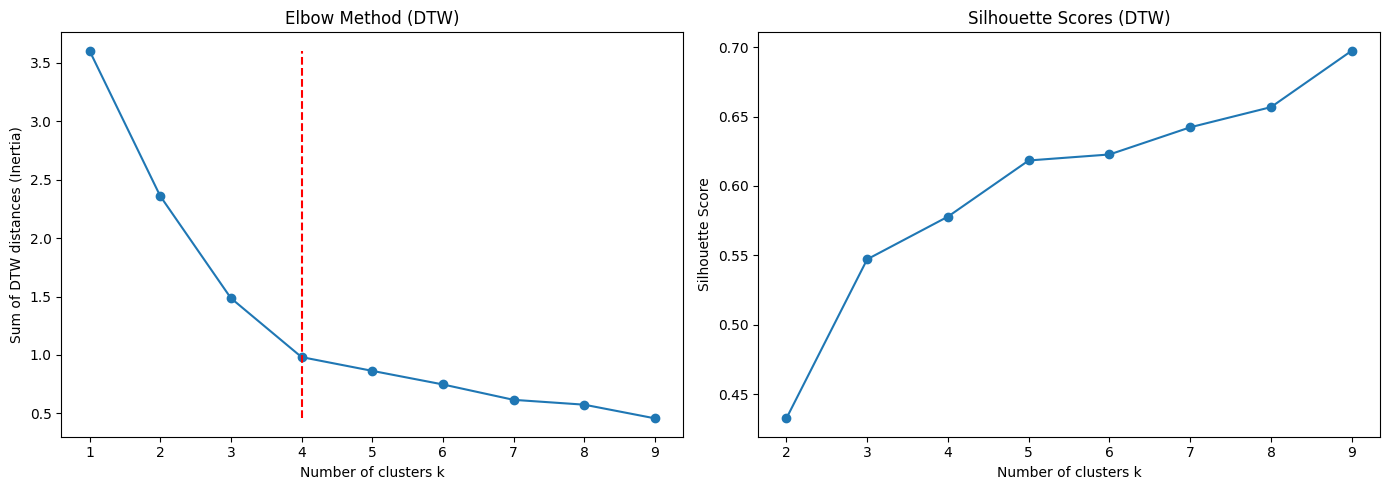

In [16]:
# -----------------------
# 1. Import libraries
# -----------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.metrics import cdist_dtw
from sklearn.metrics import silhouette_score
from kneed import KneeLocator


print("Shape of dataset:", df.shape)

# -----------------------
# 3. Scale row-wise
# -----------------------
# tslearn expects 3D array: (n_samples, n_timestamps, n_features)
X = df.values[:, :, np.newaxis]  # add 3rd dimension
scaler = TimeSeriesScalerMeanVariance()
X_scaled = scaler.fit_transform(X)

# Convert X_scaled to 2D for DataFrame/plotting: (n_genes, n_samples)
X_scaled_2d = X_scaled[:, :, 0]
scaled_df = pd.DataFrame(X_scaled_2d, index=df.index, columns=df.columns)

sz = X_scaled.shape[1]  # number of time points (samples)
print("Number of time points:", sz)


sse = []
sil_scores = []
k_range = range(1, 10)

for k in k_range:
    km = TimeSeriesKMeans(n_clusters=k, metric="dtw", random_state=42, n_init=2)
    labels = km.fit_predict(X_scaled)
    sse.append(km.inertia_)
    
    if k > 1:
        dist_matrix = cdist_dtw(X_scaled)
        score = silhouette_score(dist_matrix, labels, metric='precomputed')
        sil_scores.append(score)
    else:
        sil_scores.append(np.nan)

# -----------------------
# 4. Detect elbow
# -----------------------
knee = KneeLocator(k_range, sse, curve='convex', direction='decreasing')
print("Suggested k (elbow method):", knee.knee)

# -----------------------
# 5. Plot elbow and silhouette side by side
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(k_range, sse, marker='o')
axes[0].vlines(knee.knee, ymin=min(sse), ymax=max(sse), colors='r', linestyles='dashed')
axes[0].set_title("Elbow Method (DTW)")
axes[0].set_xlabel("Number of clusters k")
axes[0].set_ylabel("Sum of DTW distances (Inertia)")

# Silhouette plot
axes[1].plot(k_range[1:], sil_scores[1:], marker='o')
axes[1].set_title("Silhouette Scores (DTW)")
axes[1].set_xlabel("Number of clusters k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(range(2, 10))

plt.tight_layout()
plt.show()

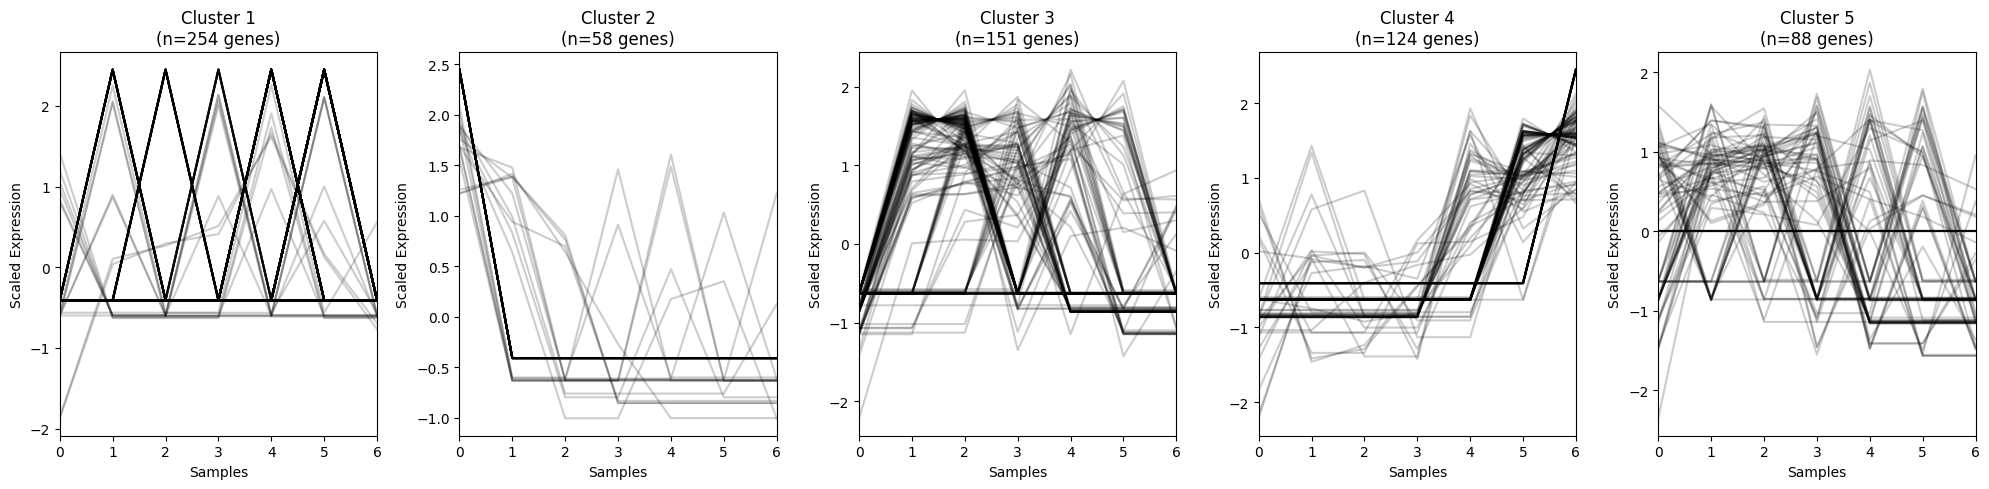

Silhouette Score (DTW) for k=5: 0.6183


In [17]:
# DTW Clustering
# -----------------------
n_clusters = 5  # choose your k
km = TimeSeriesKMeans(n_clusters=n_clusters, metric="dtw", random_state=42, n_init=2, max_iter_barycenter=10)
labels = km.fit_predict(X_scaled)

scaled_df['cluster'] = labels

# -----------------------
# 4. Plot clusters (scaled data)
# -----------------------
plt.figure(figsize=(4 * n_clusters, 5))

for cluster in range(n_clusters):
    cluster_data = scaled_df[scaled_df['cluster'] == cluster].drop(columns='cluster')
    
    plt.subplot(1, n_clusters, cluster + 1)
    
    # Plot all genes in black
    for _, row in cluster_data.iterrows():
        plt.plot(row.values, color='black', alpha=0.2)
    
    # Plot DTW barycenter in red
    #plt.plot(km.cluster_centers_[cluster].ravel(), color='red', linewidth=2)
    
    plt.title(f'Cluster {cluster+1}\n(n={cluster_data.shape[0]} genes)')
    plt.xlabel('Samples')
    plt.ylabel('Scaled Expression')
    plt.xlim(0, cluster_data.shape[1]-1)

plt.tight_layout()
plt.show()

# -----------------------
# 5. Silhouette Score (Euclidean on scaled data)
# -----------------------
dtw_dist_matrix = cdist_dtw(X_scaled)  # shape: (n_genes, n_genes)

#  Compute silhouette score with precomputed distances
score = silhouette_score(dtw_dist_matrix, labels, metric='precomputed')

print(f"Silhouette Score (DTW) for k={len(np.unique(labels))}: {score:.4f}")


In [18]:
df.head()

,weight_1,weight_2,weight_3,weight_4,weight_5,weight_6,weight_7
Reg,,,,,,,
YPR182W_YOL039W,0.010540,0.0,0.0,0.0,0.0108,0.0,0.000000
snR77_YBR252W,0.010698,0.0,0.0,0.0,0.0000,0.0,0.000000
snR77_YLR062C,0.011013,0.0,0.0,0.0,0.0000,0.0,0.000000
snR77_YGR063C,0.012532,0.0,0.0,0.0,0.0000,0.0,0.000000
snR77_YLR402W,0.040704,0.0,0.0,0.0,0.0000,0.0,0.029929


In [19]:
df.head()

,weight_1,weight_2,weight_3,weight_4,weight_5,weight_6,weight_7
Reg,,,,,,,
YPR182W_YOL039W,0.010540,0.0,0.0,0.0,0.0108,0.0,0.000000
snR77_YBR252W,0.010698,0.0,0.0,0.0,0.0000,0.0,0.000000
snR77_YLR062C,0.011013,0.0,0.0,0.0,0.0000,0.0,0.000000
snR77_YGR063C,0.012532,0.0,0.0,0.0,0.0000,0.0,0.000000
snR77_YLR402W,0.040704,0.0,0.0,0.0,0.0000,0.0,0.029929


Constant rows: 15, Active rows: 660


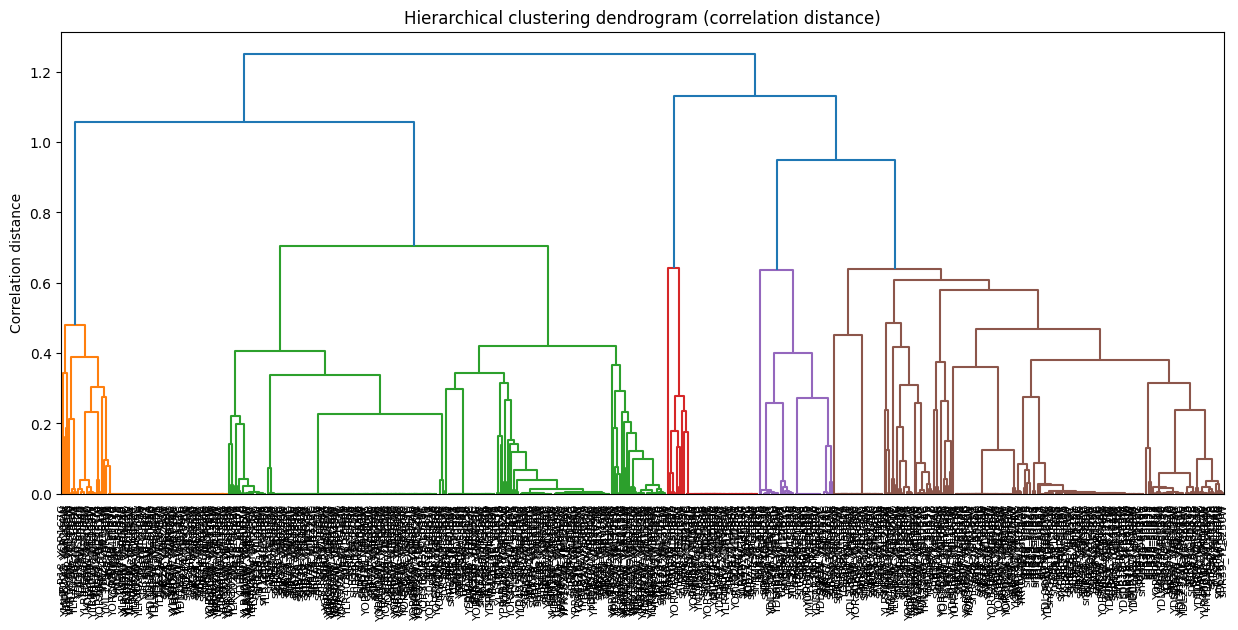

Silhouette score for k=2: 0.430
Silhouette score for k=3: 0.450
Silhouette score for k=4: 0.515
Silhouette score for k=5: 0.527
Silhouette score for k=6: 0.580
Silhouette score for k=7: 0.539
Silhouette score for k=8: 0.533
Silhouette score for k=9: 0.525
Silhouette score for k=10: 0.550
Silhouette score for k=11: 0.556
Silhouette score for k=12: 0.547
Silhouette score for k=13: 0.541
Silhouette score for k=14: 0.593
Silhouette score for k=15: 0.589


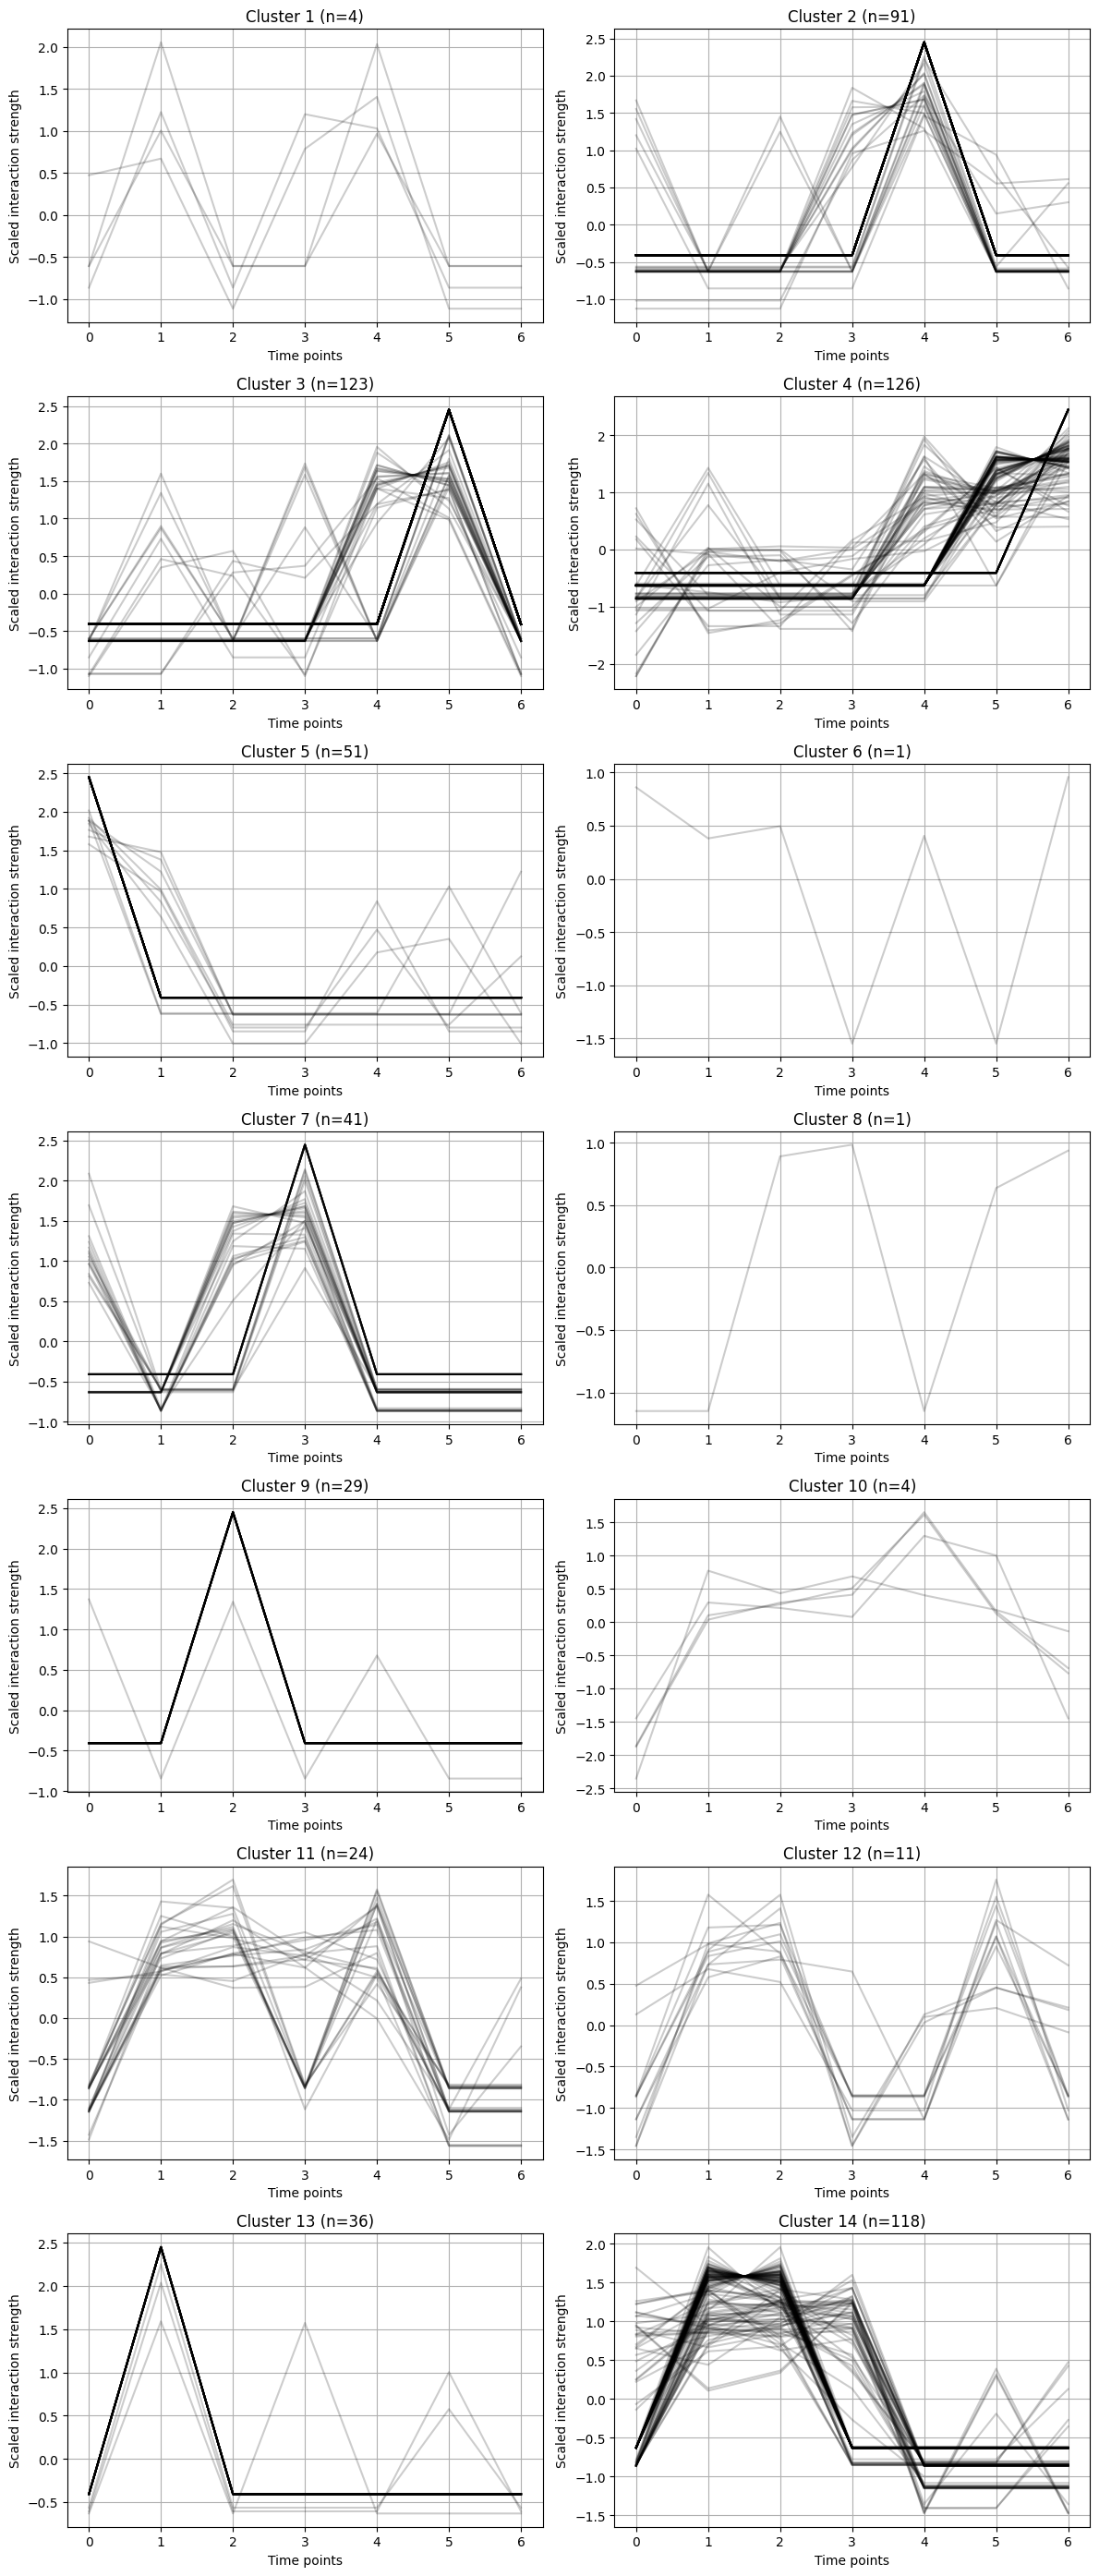

Average silhouette score = 0.59


In [20]:
import pandas as pd
import numpy as np
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import math

# -----------------------
# 1. Separate constant rows
# -----------------------
weight_cols = [c for c in df.columns if c.startswith("weight_")]

# Constant rows: std == 0
constant_mask = df[weight_cols].std(axis=1) == 0
df_constant = df[constant_mask].copy()  # all constant rows
df_active = df[~constant_mask].copy()   # only variable rows

print(f"Constant rows: {df_constant.shape[0]}, Active rows: {df_active.shape[0]}")

# -----------------------
# 2. Scale active rows
# -----------------------
X = df_active[weight_cols].values
X_scaled = X.reshape(X.shape[0], X.shape[1], 1)  # tslearn expects 3D
scaler = TimeSeriesScalerMeanVariance()
X_scaled = scaler.fit_transform(X_scaled)
X_scaled_2d = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1])

# -----------------------
# 3. Correlation distance
# -----------------------
corr = np.corrcoef(X_scaled_2d)
dist = 1 - corr
condensed_dist = squareform(dist, checks=False)

# -----------------------
# 4. Hierarchical clustering
# -----------------------
Z = linkage(condensed_dist, method='average')

# -----------------------
# 5. Plot dendrogram
# -----------------------
plt.figure(figsize=(15, 6))
dendrogram(Z, labels=df_active.index, leaf_rotation=90, leaf_font_size=8, color_threshold=0.8)
plt.title("Hierarchical clustering dendrogram (correlation distance)")
plt.ylabel("Correlation distance")
plt.show()

# 6. Silhouette analysis for different k
# -----------------------
silhouette_scores = {}
for k in range(2, 16):  # test k from 2 to 15
    cluster_labels = fcluster(Z, k, criterion='maxclust')
    score = silhouette_score(dist, cluster_labels, metric="precomputed")
    silhouette_scores[k] = score
    print(f"Silhouette score for k={k}: {score:.3f}")
# -----------------------
# 6. Choose clusters and assign
# -----------------------
n_clusters = 14 # choose based on dendrogram or silhouette
cluster_labels = fcluster(Z, n_clusters, criterion='maxclust')

# Add cluster labels to df_active
df_active["cluster"] = cluster_labels

# -----------------------
# 7. Plot line profiles per cluster
# -----------------------
cols = 2
rows = math.ceil(n_clusters / cols)
plt.figure(figsize=(cols * 6, rows * 4))

for yi in range(1, n_clusters + 1):
    ax = plt.subplot(rows, cols, yi)
    cluster_data = X_scaled_2d[cluster_labels == yi]
    
    # Plot all members in faint black lines
    for xx in cluster_data:
        ax.plot(xx.ravel(), color="k", alpha=0.2)
    
    # Plot cluster mean in red
    mean_profile = cluster_data.mean(axis=0)
    #ax.plot(mean_profile.ravel(), color="r", linewidth=2)
    
    ax.set_title(f"Cluster {yi} (n={cluster_data.shape[0]})")
    ax.set_xlabel("Time points")
    ax.set_ylabel("Scaled interaction strength")
    ax.grid(True)

plt.tight_layout()
plt.show()

# -----------------------
# 8. Silhouette score
# -----------------------
silhouette_avg = silhouette_score(dist, cluster_labels, metric="precomputed")
print(f"Average silhouette score = {silhouette_avg:.2f}")


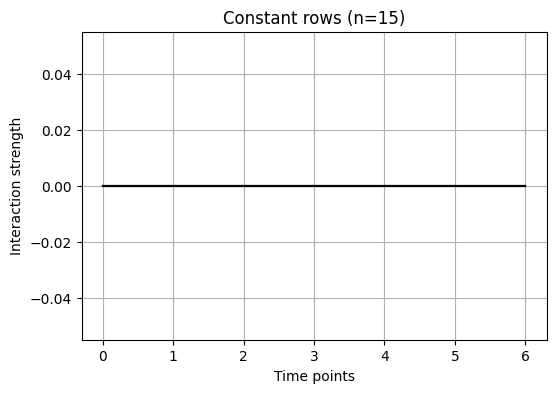

In [21]:
# constant rows get their own cluster
df_constant['cluster'] = 0  # all constant rows in cluster 0

# plot constant rows
plt.figure(figsize=(6, 4))
for _, row in df_constant[weight_cols].iterrows():
    plt.plot(row.values, color='black', alpha=0.2)
plt.title(f"Constant rows (n={df_constant.shape[0]})")
plt.xlabel("Time points")
plt.ylabel("Interaction strength")
plt.grid(True)
plt.show()


In [22]:
# encode coefficients: # 1 if >0 and <0.1, 2 if >0.1
def encode_coefficients(row):
    encoded = []
    for val in row:
        if val > 0 and val < 0.1:
            encoded.append(1)
        elif val >= 0.1:
            encoded.append(2)
        else:
            encoded.append(0)
    return encoded
features_encoded = np.array([encode_coefficients(row) for row in X])
features_encoded = pd.DataFrame(features_encoded, index=df_active.index, columns=weight_cols)


In [23]:
features_encoded. head()

,weight_1,weight_2,weight_3,weight_4,weight_5,weight_6,weight_7
Reg,,,,,,,
YPR182W_YOL039W,1,0,0,0,1,0,0
snR77_YBR252W,1,0,0,0,0,0,0
snR77_YLR062C,1,0,0,0,0,0,0
snR77_YGR063C,1,0,0,0,0,0,0
snR77_YLR402W,1,0,0,0,0,0,1


In [24]:
features_encoded.head(20)

,weight_1,weight_2,weight_3,weight_4,weight_5,weight_6,weight_7
Reg,,,,,,,
YPR182W_YOL039W,1,0,0,0,1,0,0
snR77_YBR252W,1,0,0,0,0,0,0
snR77_YLR062C,1,0,0,0,0,0,0
snR77_YGR063C,1,0,0,0,0,0,0
snR77_YLR402W,1,0,0,0,0,0,1
snR77_YDL061C,1,0,0,1,0,0,0
snR77_YML129C,1,0,0,1,0,0,0
snR77_YDR276C,1,0,0,1,0,0,0
snR77_YPL136W,1,0,0,0,0,0,0


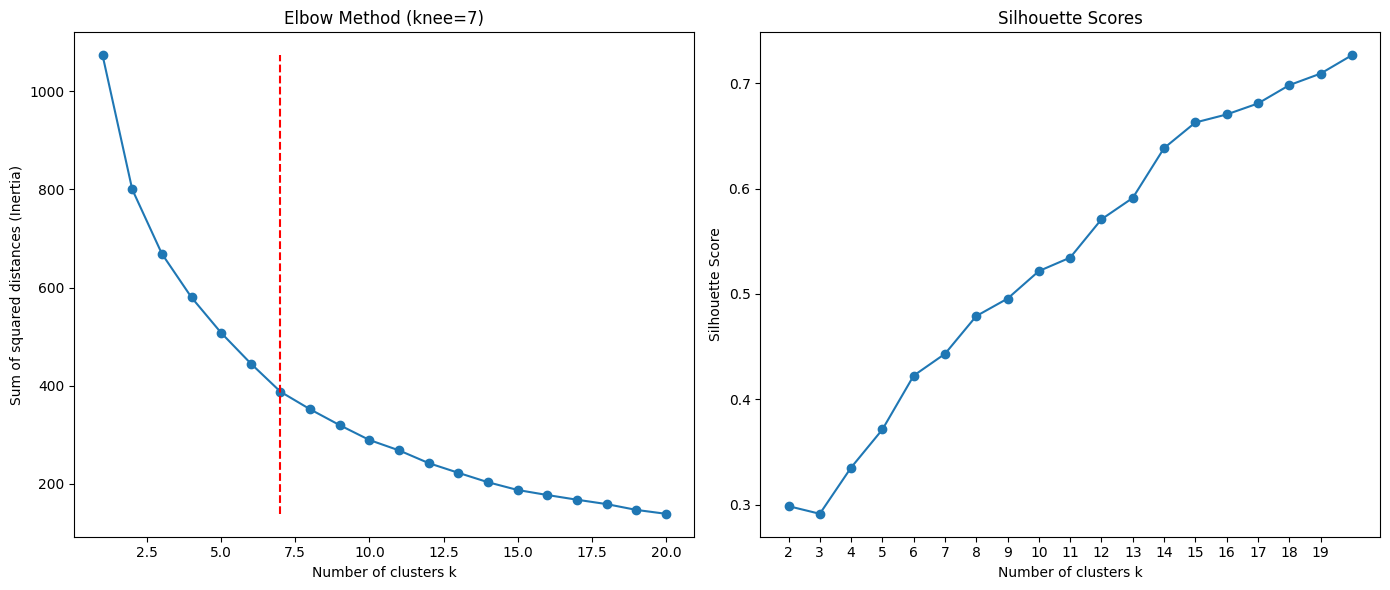

In [25]:
# KMeans (Euclidean)
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import silhouette_score
# -----------------------
# 1. elbow method
# -----------------------
sse = []
k_range = range(1, 21)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=100)
    kmeans.fit(features_encoded)
    sse.append(kmeans.inertia_)
knee = KneeLocator(k_range, sse, curve='convex', direction='decreasing')
# -----------------------
# 2. silhouette scores
# -----------------------
silhouette_scores = []
for k in range(2, 21):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=100)
    labels = kmeans.fit_predict(features_encoded)
    score = silhouette_score(features_encoded, labels)
    silhouette_scores.append(score)
# -----------------------
# 3. plot both side by side
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Elbow plot
axes[0].plot(k_range, sse, marker='o')
if knee.knee is not None:
    axes[0].vlines(knee.knee, ymin=min(sse), ymax=max(sse), colors='r', linestyles='dashed')
    axes[0].set_title(f'Elbow Method (knee={knee.knee})')
else:
    axes[0].set_title("Elbow Method (no clear knee)")
axes[0].set_xlabel('Number of clusters k')
axes[0].set_ylabel('Sum of squared distances (Inertia)')  

# Silhouette plot
axes[1].plot(range(2, 21), silhouette_scores, marker='o')
axes[1].set_title("Silhouette Scores")
axes[1].set_xlabel('Number of clusters k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(range(2, 20))
plt.tight_layout()
plt.show()



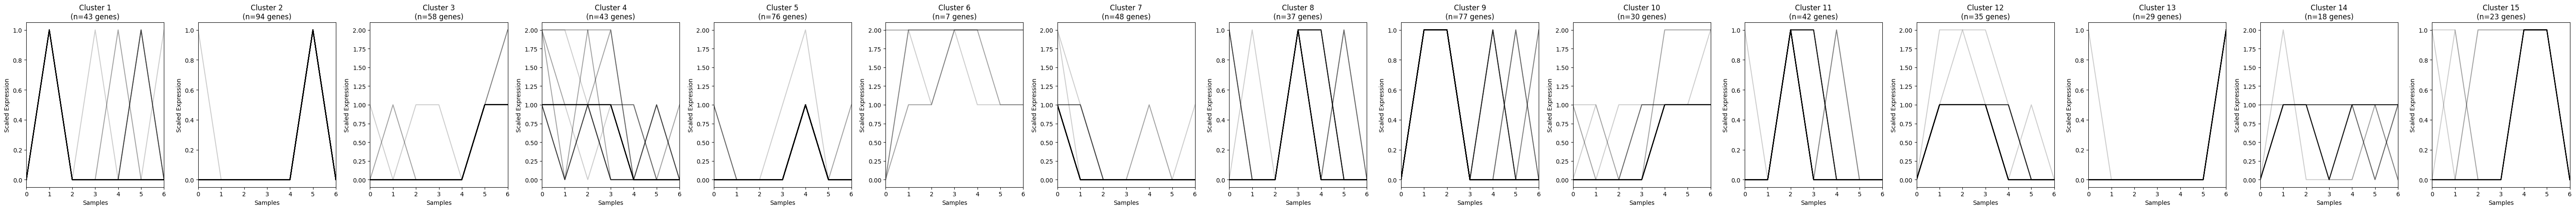

Silhouette Score for k=15: 0.6626


In [26]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

# -----------------------
# 1. KMeans clustering
# -----------------------
n_clusters = 15
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=100)
labels = kmeans.fit_predict(features_encoded)

# Add cluster labels to the DataFrame
features_encoded['cluster'] = labels

# -----------------------
# 2. Plot clusters side by side
# -----------------------
plt.figure(figsize=(4 * n_clusters, 5))  # width scales with number of clusters

for cluster in range(n_clusters):
    cluster_data = features_encoded[features_encoded['cluster'] == cluster].drop(columns='cluster')
    
    plt.subplot(1, n_clusters, cluster + 1)
    
    # Plot all genes in black
    for index, row in cluster_data.iterrows():
        plt.plot(row.values, color='black', alpha=0.2)
    
    # Plot mean profile in red
    mean_profile = cluster_data.mean(axis=0)
    #plt.plot(mean_profile.values, color='red', linewidth=2)
    
    plt.title(f'Cluster {cluster+1}\n(n={cluster_data.shape[0]} genes)')
    plt.xlabel('Samples')
    plt.ylabel('Scaled Expression')
    plt.xlim(0, cluster_data.shape[1]-1)

plt.tight_layout()
plt.show()
# print sillhouette score
score = silhouette_score(features_encoded.drop(columns='cluster'), labels)
print(f'Silhouette Score for k={n_clusters}: {score:.4f}')


In [27]:
# if features encoded contnain cluster column, drop it

if 'cluster' in features_encoded.columns:
    features_encoded= features_encoded.drop(columns='cluster')


In [28]:
import pandas as pd
import numpy as np

# df contains weight_1 ... weight_7
weight_cols = [c for c in df.columns if c.startswith("weight_")]

X = df[weight_cols].values

# Binarize: 1 if present, 0 if not
X_bin = (X > 0).astype(int)

def temporal_pattern(row):
    n_timepoints = len(row)
    total_present = row.sum()
    
    # Always expressed
    if total_present == n_timepoints:
        return "always"
    
    # Beginning: more expressed in first half
    if row[:n_timepoints//2].sum() >= row[n_timepoints//2:].sum():
        return "beginning"
    
    # End: more expressed in second half
    if row[n_timepoints//2:].sum() > row[:n_timepoints//2].sum():
        return "end"
    
    # Middle: expressed mostly in middle time points
    mid_start = n_timepoints//4
    mid_end = n_timepoints - mid_start
    if row[mid_start:mid_end].sum() > max(row[:mid_start].sum(), row[mid_end:].sum()):
        return "middle"
    
    return "other"

patterns = np.apply_along_axis(temporal_pattern, 1, X_bin)

# Add pattern labels to DataFrame
df['temporal_pattern'] = patterns
df.head(30)


,weight_1,weight_2,weight_3,weight_4,weight_5,weight_6,weight_7,temporal_pattern
Reg,,,,,,,,
YPR182W_YOL039W,0.010540,0.000000,0.000000,0.000000,0.010800,0.000000,0.000000,beginning
snR77_YBR252W,0.010698,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,beginning
snR77_YLR062C,0.011013,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,beginning
snR77_YGR063C,0.012532,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,beginning
snR77_YLR402W,0.040704,0.000000,0.000000,0.000000,0.000000,0.000000,0.029929,beginning
snR77_YDL061C,0.038971,0.000000,0.000000,0.073967,0.000000,0.000000,0.000000,beginning
snR77_YML129C,0.045761,0.000000,0.000000,0.089311,0.000000,0.000000,0.000000,beginning
snR77_YDR276C,0.035709,0.000000,0.000000,0.056059,0.000000,0.000000,0.000000,beginning
snR77_YPL136W,0.013388,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,beginning


In [29]:
# One-hot encoding of patterns
pattern_encoded = pd.get_dummies(df['temporal_pattern'])

# Optionally include mean or peak values as additional features
pattern_features = pd.concat([pattern_encoded,
                              df[weight_cols].mean(axis=1).rename("mean"),
                              df[weight_cols].max(axis=1).rename("max")],
                             axis=1)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
X_scaled = scaler.fit_transform(pattern_features)

kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)


k=2: inertia=2029.91, silhouette=0.6810
k=3: inertia=1172.74, silhouette=0.7012
k=4: inertia=587.78, silhouette=0.7490
k=5: inertia=464.03, silhouette=0.7549
k=6: inertia=300.20, silhouette=0.7455
k=7: inertia=221.56, silhouette=0.7339
k=8: inertia=165.43, silhouette=0.7344
k=9: inertia=147.35, silhouette=0.6650
k=10: inertia=126.99, silhouette=0.6674


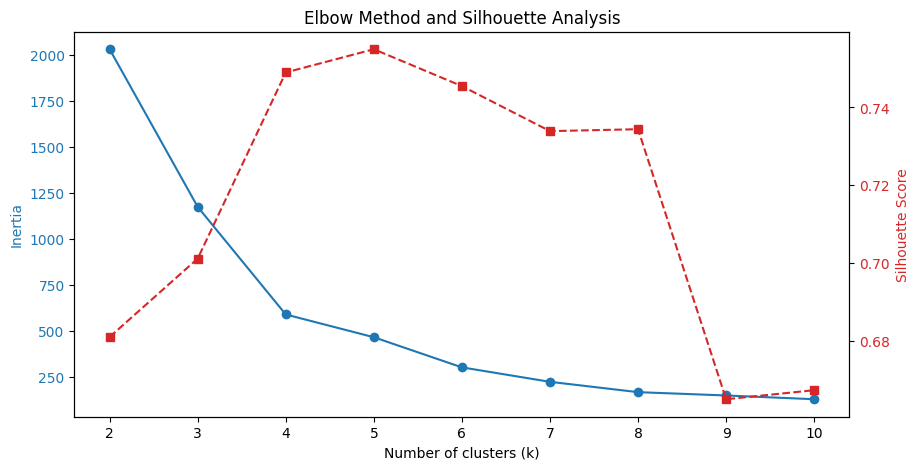

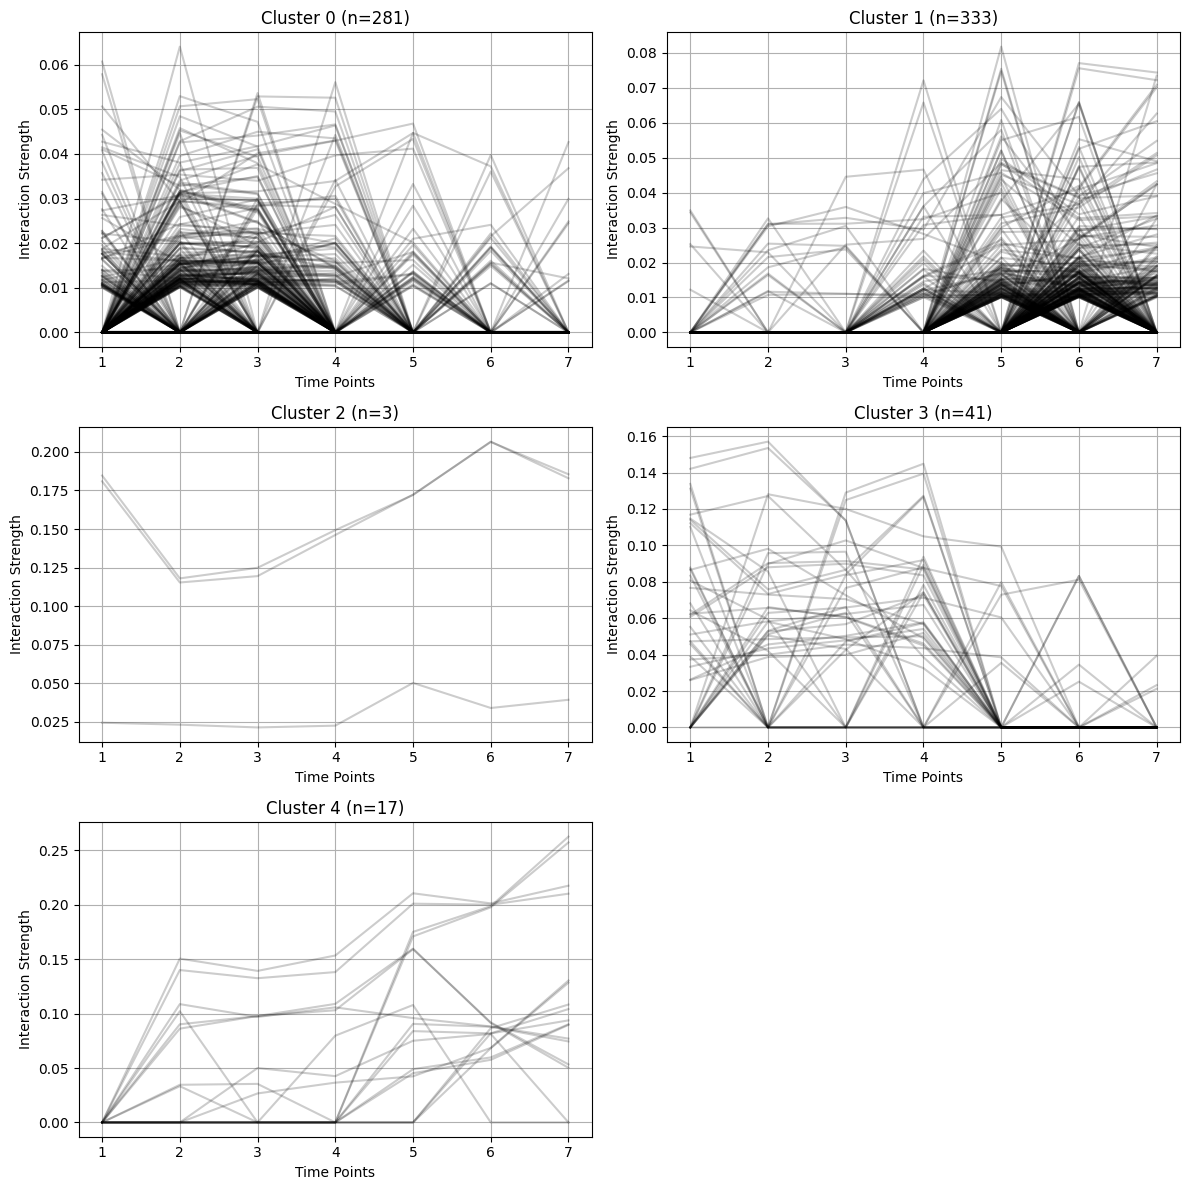

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# -----------------------
# 1. Prepare temporal pattern features
# -----------------------
weight_cols = [c for c in df.columns if c.startswith("weight_")]
X = df[weight_cols].values

# Binarize: 1 if expressed, 0 if not
X_bin = (X > 0).astype(int)

def temporal_pattern(row):
    n_timepoints = len(row)
    total_present = row.sum()
    
    if total_present >= n_timepoints:
        return "always"
    # Beginning
    if row[:n_timepoints//2].sum() >= row[n_timepoints//2:].sum():
        return "beginning"
    # End
    if row[n_timepoints//2:].sum() > row[:n_timepoints//2].sum():
        return "end"
    # Middle
    mid_start = n_timepoints//4
    mid_end = n_timepoints - mid_start
    if row[mid_start:mid_end].sum() > max(row[:mid_start].sum(), row[mid_end:].sum()):
        return "middle"
    return "other"

patterns = np.apply_along_axis(temporal_pattern, 1, X_bin)
df['temporal_pattern'] = patterns

# One-hot encode patterns
pattern_encoded = pd.get_dummies(df['temporal_pattern'])
pattern_features = pd.concat([pattern_encoded,
                              df[weight_cols].mean(axis=1).rename("mean"),
                              df[weight_cols].max(axis=1).rename("max")],
                             axis=1)

# -----------------------
# 2. Scale features
# -----------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pattern_features)

# -----------------------
# 3. Elbow + Silhouette Analysis
# -----------------------
k_values = range(2, 11)
inertia = []
sil_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    print(f"k={k}: inertia={kmeans.inertia_:.2f}, silhouette={sil_scores[-1]:.4f}")

# Plot Elbow + Silhouette
fig, ax1 = plt.subplots(figsize=(10,5))
color = 'tab:blue'
ax1.plot(k_values, inertia, 'o-', color=color)
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia', color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.plot(k_values, sil_scores, 's--', color=color)
ax2.set_ylabel('Silhouette Score', color=color)
ax2.tick_params(axis='y', labelcolor=color)
plt.title("Elbow Method and Silhouette Analysis")
plt.show()

# -----------------------
# 4. Final clustering (choose k)
# -----------------------
n_clusters = 5  # or choose based on elbow/silhouette
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# -----------------------
# 5. Plot each cluster separately
# -----------------------
time_points = range(1, len(weight_cols)+1)
cols = 2
rows = int(np.ceil(n_clusters / cols))
plt.figure(figsize=(cols*6, rows*4))

for c in range(n_clusters):
    ax = plt.subplot(rows, cols, c+1)
    cluster_data = df[df['cluster']==c][weight_cols]
    
    # Plot all members as faint lines
    for idx, row in cluster_data.iterrows():
        ax.plot(time_points, row.values, color='k', alpha=0.2)
    
    # Plot cluster mean
    mean_profile = cluster_data.mean()
    #ax.plot(time_points, mean_profile.values, color='r', linewidth=2)
    
    ax.set_title(f"Cluster {c} (n={cluster_data.shape[0]})")
    ax.set_xlabel("Time Points")
    ax.set_ylabel("Interaction Strength")
    ax.grid(True)

plt.tight_layout()
plt.show()


In [31]:
df.head()

,weight_1,weight_2,weight_3,weight_4,weight_5,weight_6,weight_7,temporal_pattern,cluster
Reg,,,,,,,,,
YPR182W_YOL039W,0.010540,0.0,0.0,0.0,0.0108,0.0,0.000000,beginning,0
snR77_YBR252W,0.010698,0.0,0.0,0.0,0.0000,0.0,0.000000,beginning,0
snR77_YLR062C,0.011013,0.0,0.0,0.0,0.0000,0.0,0.000000,beginning,0
snR77_YGR063C,0.012532,0.0,0.0,0.0,0.0000,0.0,0.000000,beginning,0
snR77_YLR402W,0.040704,0.0,0.0,0.0,0.0000,0.0,0.029929,beginning,0


In [32]:
df= pd.read_csv("input_data/Yeast_consolidated_gene_regulation_network.csv")

# remove duplicate rows
df = df.drop_duplicates()
df.shape
# replace values with 0 if lower than 0.01
df[df.iloc[:,1:].abs() < 0.01] = 0
df.set_index('Reg', inplace=True)
df.head(20)

,weight_1,weight_2,weight_3,weight_4,weight_5,weight_6,weight_7
Reg,,,,,,,
YPR182W_YOL039W,0.010540,0.0,0.0,0.000000,0.0108,0.0,0.000000
snR77_YBR252W,0.010698,0.0,0.0,0.000000,0.0000,0.0,0.000000
snR77_YLR062C,0.011013,0.0,0.0,0.000000,0.0000,0.0,0.000000
snR77_YGR063C,0.012532,0.0,0.0,0.000000,0.0000,0.0,0.000000
snR77_YLR402W,0.040704,0.0,0.0,0.000000,0.0000,0.0,0.029929
snR77_YDL061C,0.038971,0.0,0.0,0.073967,0.0000,0.0,0.000000
snR77_YML129C,0.045761,0.0,0.0,0.089311,0.0000,0.0,0.000000
snR77_YDR276C,0.035709,0.0,0.0,0.056059,0.0000,0.0,0.000000
snR77_YPL136W,0.013388,0.0,0.0,0.000000,0.0000,0.0,0.000000


In [33]:
df.head()

,weight_1,weight_2,weight_3,weight_4,weight_5,weight_6,weight_7
Reg,,,,,,,
YPR182W_YOL039W,0.010540,0.0,0.0,0.0,0.0108,0.0,0.000000
snR77_YBR252W,0.010698,0.0,0.0,0.0,0.0000,0.0,0.000000
snR77_YLR062C,0.011013,0.0,0.0,0.0,0.0000,0.0,0.000000
snR77_YGR063C,0.012532,0.0,0.0,0.0,0.0000,0.0,0.000000
snR77_YLR402W,0.040704,0.0,0.0,0.0,0.0000,0.0,0.029929


k=2: inertia=0.05, silhouette=0.1260
k=3: inertia=0.03, silhouette=0.1270
k=4: inertia=0.03, silhouette=0.0769
k=5: inertia=0.03, silhouette=0.0756
k=6: inertia=0.02, silhouette=0.0603
k=7: inertia=0.02, silhouette=0.1321
k=8: inertia=0.02, silhouette=0.1181
k=9: inertia=0.01, silhouette=0.0365
k=10: inertia=0.01, silhouette=0.0206
k=11: inertia=0.02, silhouette=-0.0006
k=12: inertia=0.01, silhouette=0.0574
k=13: inertia=0.01, silhouette=0.0735
k=14: inertia=0.01, silhouette=0.0122
k=15: inertia=0.01, silhouette=0.0111
k=16: inertia=0.01, silhouette=0.1809
k=17: inertia=0.01, silhouette=0.1747
k=18: inertia=inf, silhouette=0.2765
k=19: inertia=inf, silhouette=0.1866
k=20: inertia=inf, silhouette=0.2236


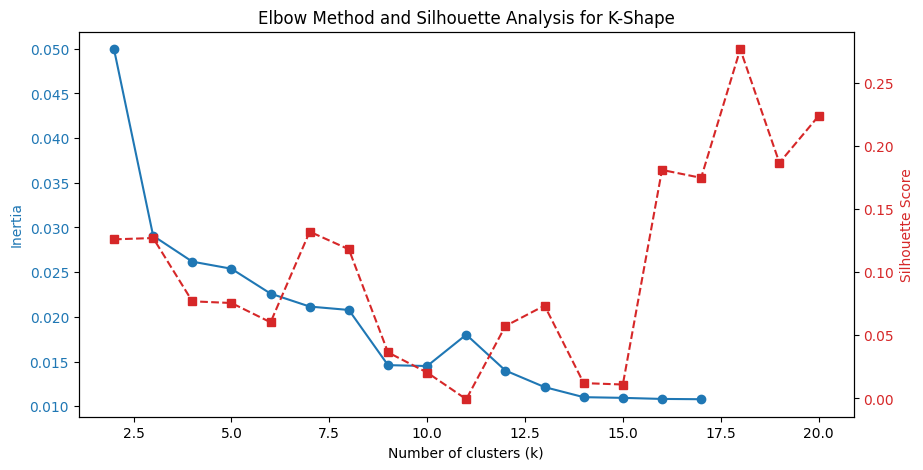

In [34]:
from tslearn.clustering import KShape
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# --- Prepare time-series data ---
weight_cols = [c for c in df.columns if c.startswith("weight_")]
X = df[weight_cols].values
X_reshaped = X[:, :, np.newaxis]

# --- Normalize each time series ---
scaler = TimeSeriesScalerMeanVariance()
X_scaled = scaler.fit_transform(X_reshaped)

# --- Elbow + Silhouette Analysis ---
inertias = []
sil_scores = []
k_range = range(2, 21)

for k in k_range:
    ks = KShape(n_clusters=k, random_state=42)
    labels = ks.fit_predict(X_scaled)
    
    inertias.append(ks.inertia_)
    
    # Flatten time series for silhouette score
    X_flat = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1])
    sil = silhouette_score(X_flat, labels)
    sil_scores.append(sil)
    print(f"k={k}: inertia={ks.inertia_:.2f}, silhouette={sil:.4f}")

# --- Plot Elbow and Silhouette ---
fig, ax1 = plt.subplots(figsize=(10, 5))
color = 'tab:blue'
ax1.plot(k_range, inertias, 'o-', color=color)
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.plot(k_range, sil_scores, 's--', color=color)
ax2.set_ylabel('Silhouette Score', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Elbow Method and Silhouette Analysis for K-Shape")
plt.show()

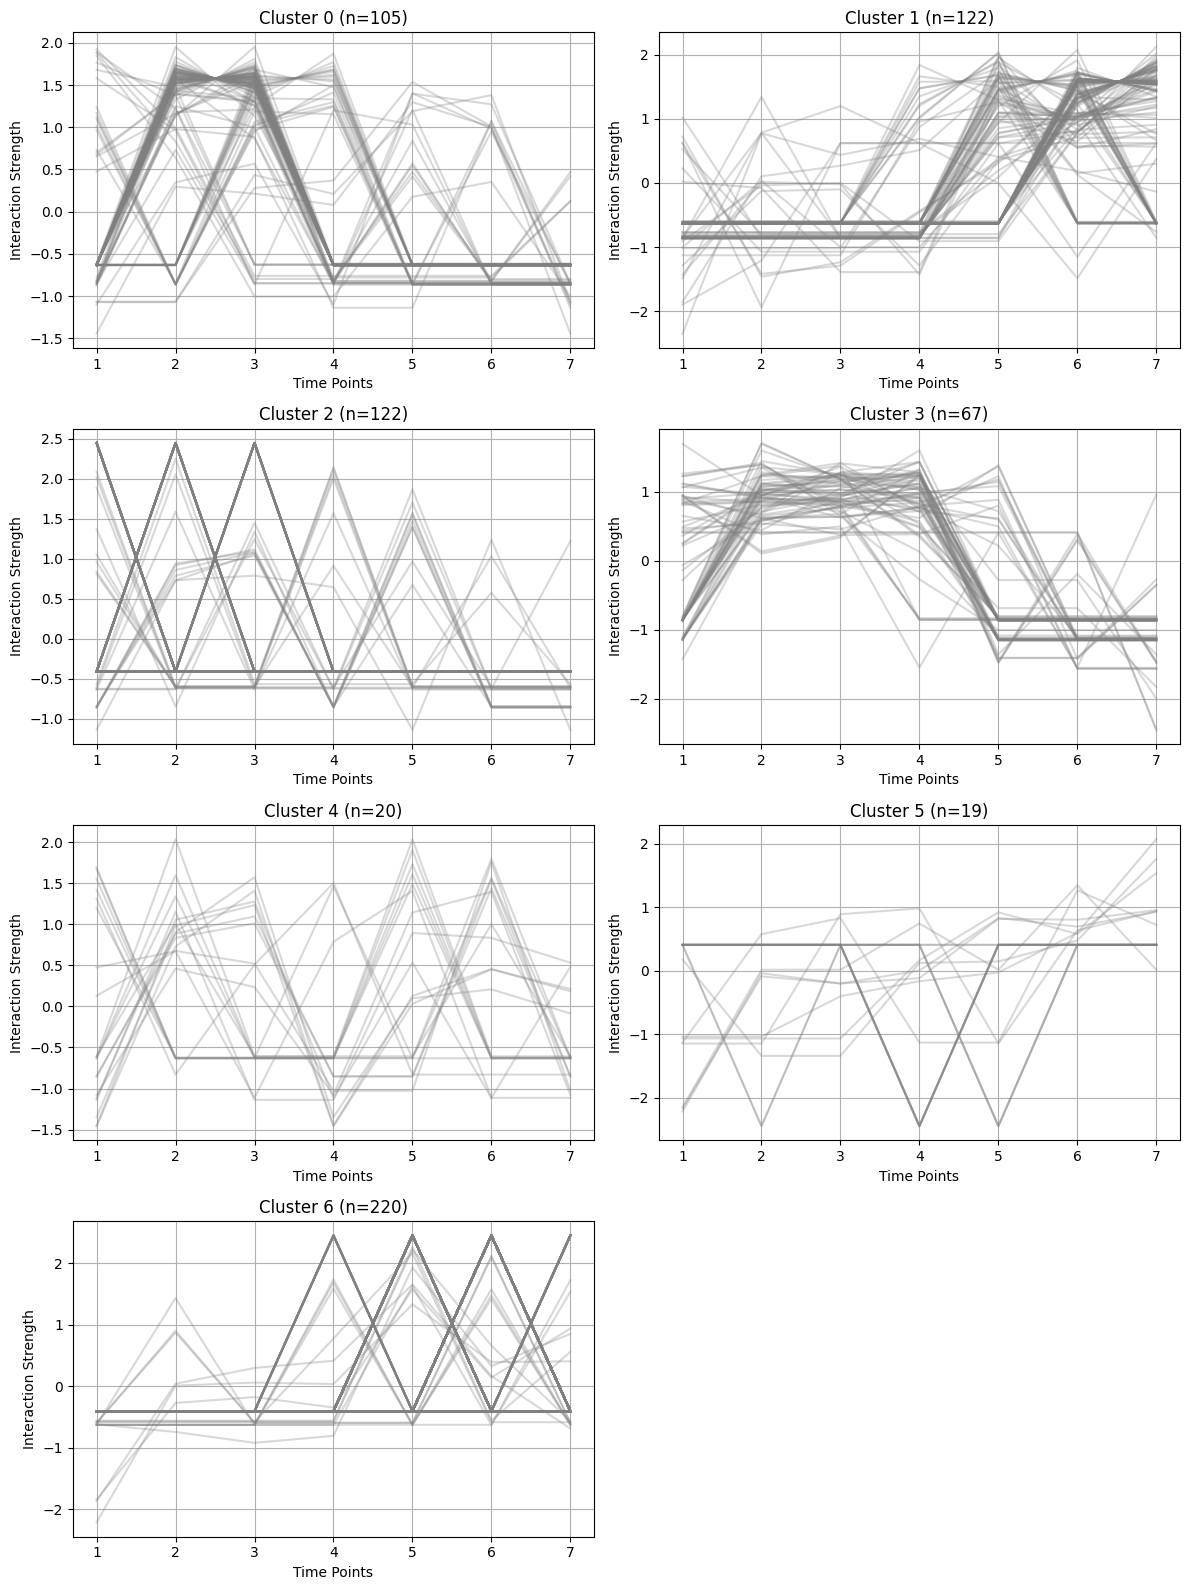

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tslearn.clustering import KShape
from tslearn.preprocessing import TimeSeriesScalerMeanVariance

# --- 1. Prepare time-series data ---
weight_cols = [c for c in df.columns if c.startswith("weight_")]
X = df[weight_cols].values

# Reshape to 3D array: (n_samples, n_timestamps, 1)
X_reshaped = X[:, :, np.newaxis]

# --- 2. Normalize each time series ---
scaler = TimeSeriesScalerMeanVariance()
X_scaled = scaler.fit_transform(X_reshaped)

# --- 3. Apply K-Shape clustering ---
n_clusters = 7  # You can tune this
ks = KShape(n_clusters=n_clusters, random_state=42)
labels = ks.fit_predict(X_scaled)
df['cluster_kshape'] = labels

# --- 4. Plot clusters ---
time_points = range(1, len(weight_cols)+1)
cols = 2
rows = int(np.ceil(n_clusters / cols))
plt.figure(figsize=(cols*6, rows*4))

for c in range(n_clusters):
    ax = plt.subplot(rows, cols, c+1)
    cluster_indices = np.where(labels == c)[0]
    
    for idx in cluster_indices:
        ax.plot(time_points, X_scaled[idx].flatten(), color='gray', alpha=0.3)
    
    # Plot cluster centroid
    centroid = ks.cluster_centers_[c].flatten()
    #ax.plot(time_points, centroid, color='red', linewidth=2)
    
    ax.set_title(f"Cluster {c} (n={len(cluster_indices)})")
    ax.set_xlabel("Time Points")
    ax.set_ylabel("Interaction Strength")
    ax.grid(True)

plt.tight_layout()
plt.show()


In [36]:

# Constant rows: std == 0
constant_mask = df[weight_cols].std(axis=1) == 0
df_constant = df[constant_mask].copy()  # all constant rows
df_active = df[~constant_mask].copy()   # only variable rows

print(f"Constant rows: {df_constant.shape[0]}, Active rows: {df_active.shape[0]}")

# Use only active rows for encoding
X_active = df_active[weight_cols].values


# encode coefficients:
# 1 if 0 < val < 0.1
# 0 otherwise
def encode_coefficients(row):
    encoded = []
    for val in row:
        if 0 < val < 0.1:
            encoded.append(1)
        elif val <= -0.1:
            encoded.append(-1)
        else:
            encoded.append(0)
    return encoded

features_encoded = np.array([encode_coefficients(row) for row in X_active])
features_encoded = pd.DataFrame(features_encoded, index=df_active.index, columns=weight_cols)


Constant rows: 0, Active rows: 675


In [37]:
features_encoded.head()

,weight_1,weight_2,weight_3,weight_4,weight_5,weight_6,weight_7
Reg,,,,,,,
YPR182W_YOL039W,1,0,0,0,1,0,0
snR77_YBR252W,1,0,0,0,0,0,0
snR77_YLR062C,1,0,0,0,0,0,0
snR77_YGR063C,1,0,0,0,0,0,0
snR77_YLR402W,1,0,0,0,0,0,1


In [38]:
df.head()

,weight_1,weight_2,weight_3,weight_4,weight_5,weight_6,weight_7,cluster_kshape
Reg,,,,,,,,
YPR182W_YOL039W,0.010540,0.0,0.0,0.0,0.0108,0.0,0.000000,4
snR77_YBR252W,0.010698,0.0,0.0,0.0,0.0000,0.0,0.000000,2
snR77_YLR062C,0.011013,0.0,0.0,0.0,0.0000,0.0,0.000000,2
snR77_YGR063C,0.012532,0.0,0.0,0.0,0.0000,0.0,0.000000,2
snR77_YLR402W,0.040704,0.0,0.0,0.0,0.0000,0.0,0.029929,2


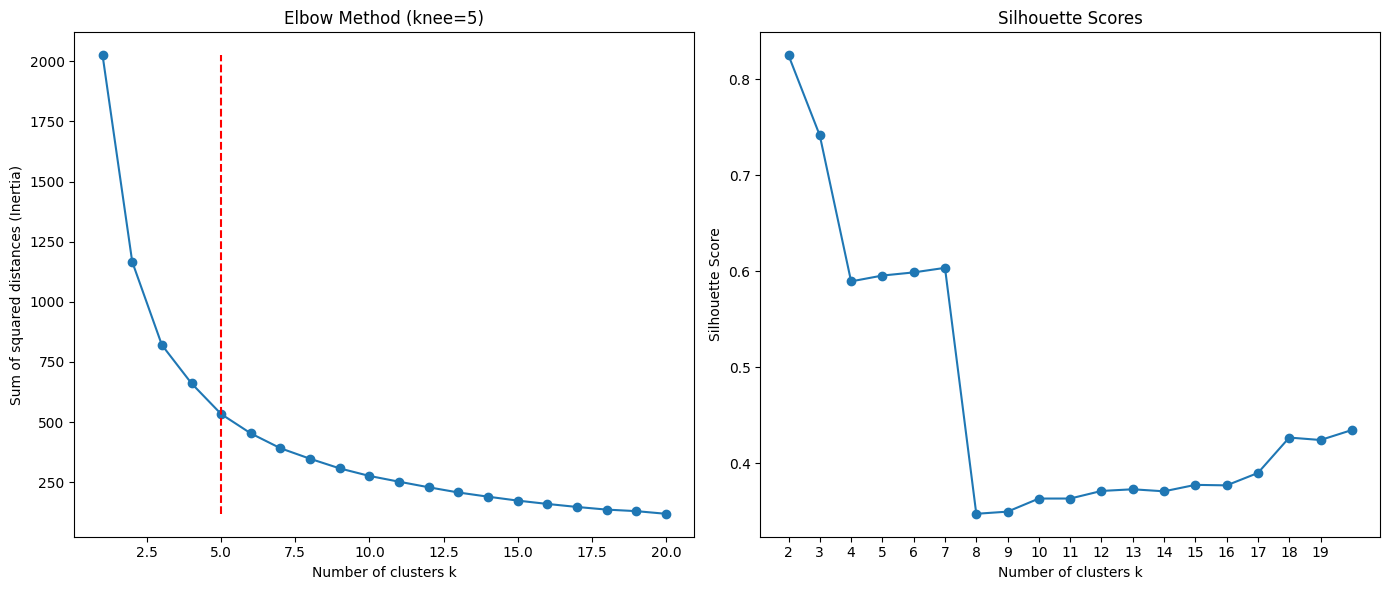

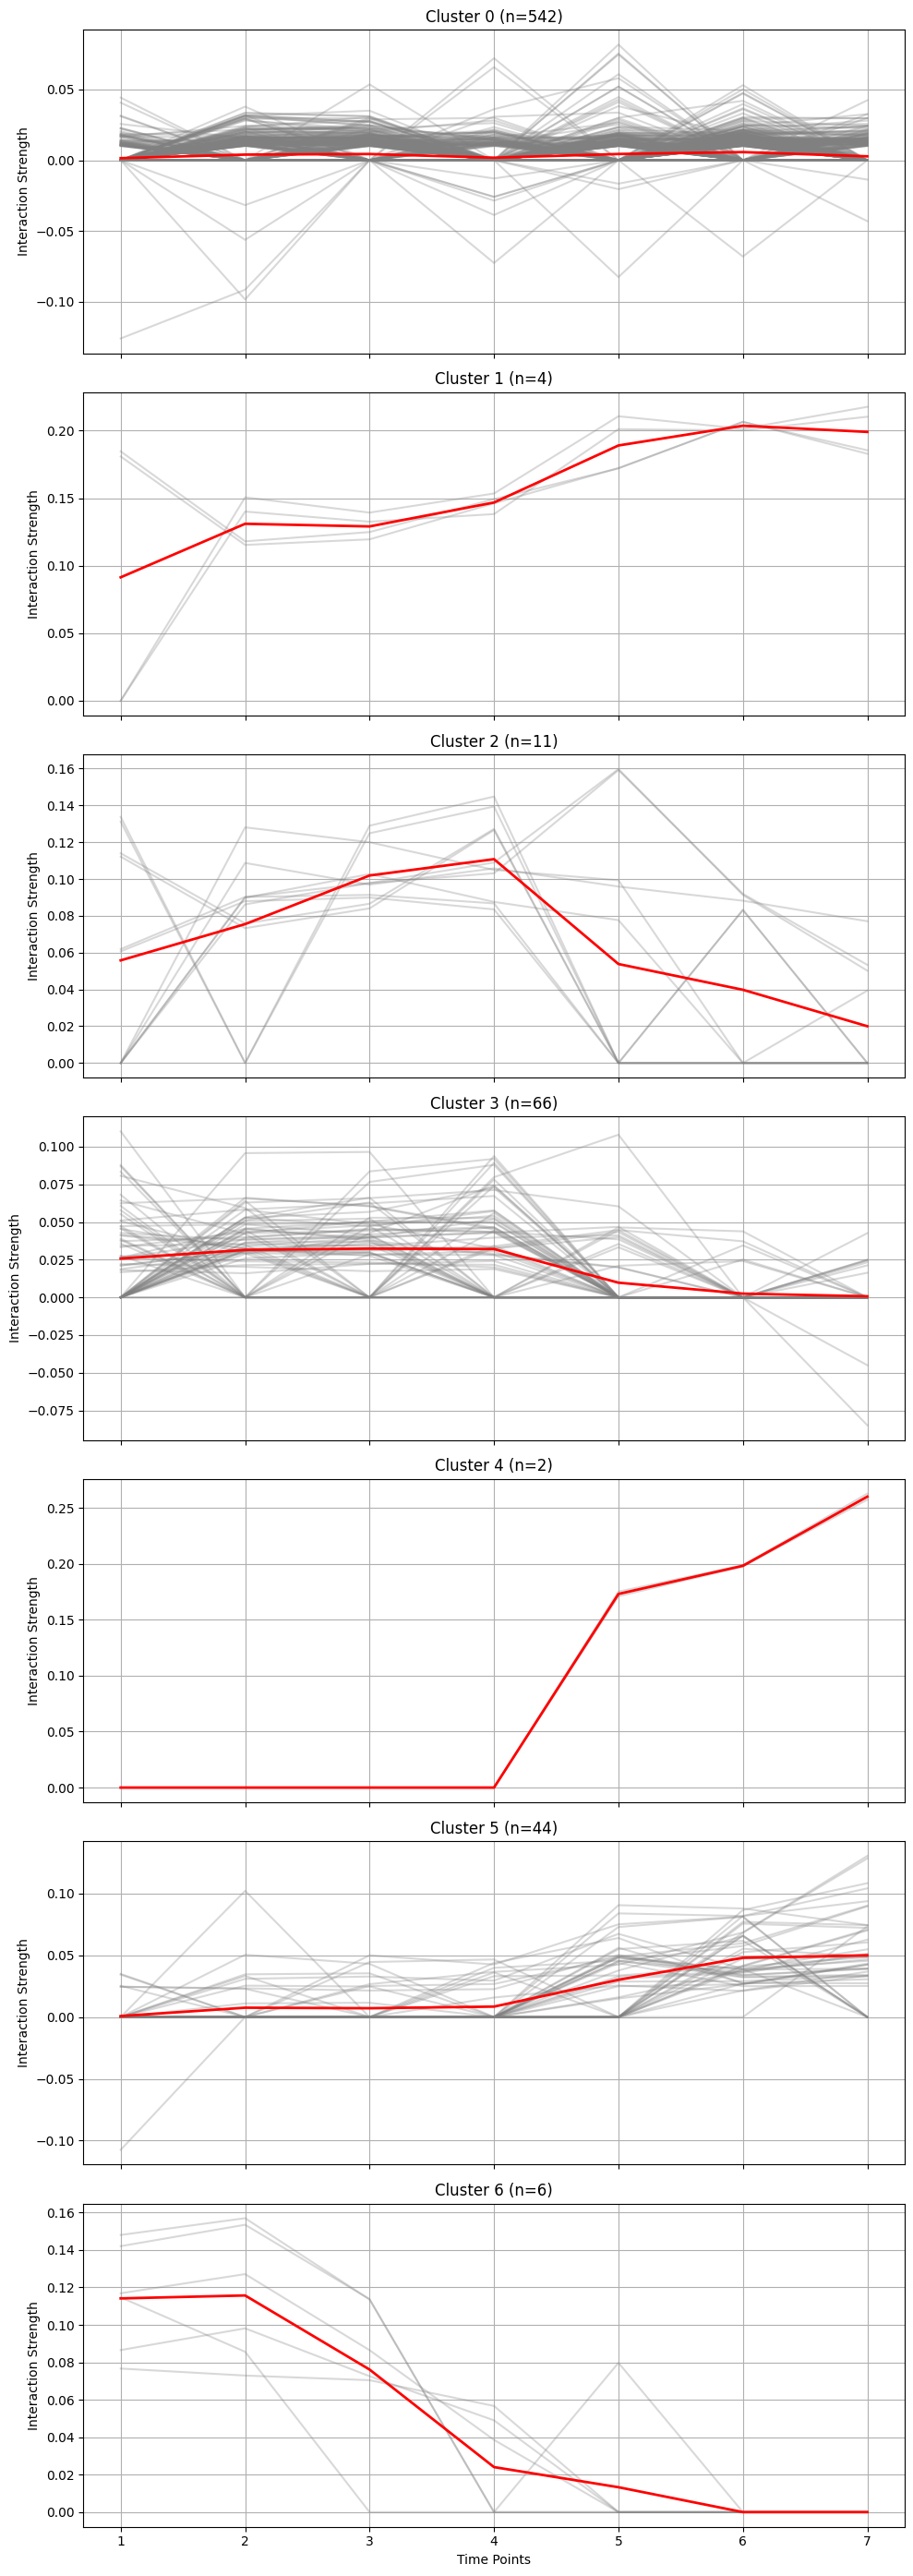

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# -------------------
# Step 1: Create frequency-based features
# -------------------
# We group time points into three phases: early, mid, and late
df_features = pd.DataFrame({
    "early": df[["weight_1", "weight_2"]].sum(axis=1),
    "mid": df[["weight_3", "weight_4", "weight_5"]].sum(axis=1),
    "late": df[["weight_6", "weight_7"]].sum(axis=1),
}, index=df.index)

# -------------------
# Step 2: Standardize features for clustering
# -------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

# elbow method
sse = []
k_range = range(1, 21)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=100)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)
knee = KneeLocator(k_range, sse, curve='convex', direction='decreasing')
# silhouette scores
silhouette_scores = []
for k in range(2, 21):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=100)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
# plot both side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Elbow plot
axes[0].plot(k_range, sse, marker='o')
if knee.knee is not None:
    axes[0].vlines(knee.knee, ymin=min(sse), ymax=max(sse), colors='r', linestyles='dashed')
    axes[0].set_title(f'Elbow Method (knee={knee.knee})')
else:
    axes[0].set_title("Elbow Method (no clear knee)")
axes[0].set_xlabel('Number of clusters k')
axes[0].set_ylabel('Sum of squared distances (Inertia)')

# Silhouette plot
axes[1].plot(range(2, 21), silhouette_scores, marker='o')
axes[1].set_title("Silhouette Scores")
axes[1].set_xlabel('Number of clusters k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(range(2, 20))
plt.tight_layout()
plt.show()


# -------------------
# Step 3: Apply KMeans clustering
# -------------------
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to original DataFrame
df["cluster"] = clusters

# -------------------
# Step 4: Plot original time-series lines per cluster
# -------------------
time_points = range(1, 8)  # Time points from weight_1 to weight_7
weight_cols = [f"weight_{i}" for i in time_points]

# Create subplots for each cluster
n_clusters = len(np.unique(clusters))
fig, axes = plt.subplots(n_clusters, 1, figsize=(10, 4 * n_clusters), sharex=True)

for c in range(n_clusters):
    ax = axes[c]
    cluster_data = df[df["cluster"] == c][weight_cols]
    
    # Plot each time-series line in the cluster
    for _, row in cluster_data.iterrows():
        ax.plot(time_points, row.values, color='gray', alpha=0.3)
    
    # Plot cluster mean profile
    mean_profile = cluster_data.mean()
    ax.plot(time_points, mean_profile.values, color='red', linewidth=2)
    
    ax.set_title(f"Cluster {c} (n={cluster_data.shape[0]})")
    ax.set_ylabel("Interaction Strength")
    ax.grid(True)

axes[-1].set_xlabel("Time Points")
plt.tight_layout()
plt.show()


In [40]:
#features_encoded= features_encoded.drop(columns="cluster_kshape")
features_encoded.head()

,weight_1,weight_2,weight_3,weight_4,weight_5,weight_6,weight_7
Reg,,,,,,,
YPR182W_YOL039W,1,0,0,0,1,0,0
snR77_YBR252W,1,0,0,0,0,0,0
snR77_YLR062C,1,0,0,0,0,0,0
snR77_YGR063C,1,0,0,0,0,0,0
snR77_YLR402W,1,0,0,0,0,0,1


#####using binary features

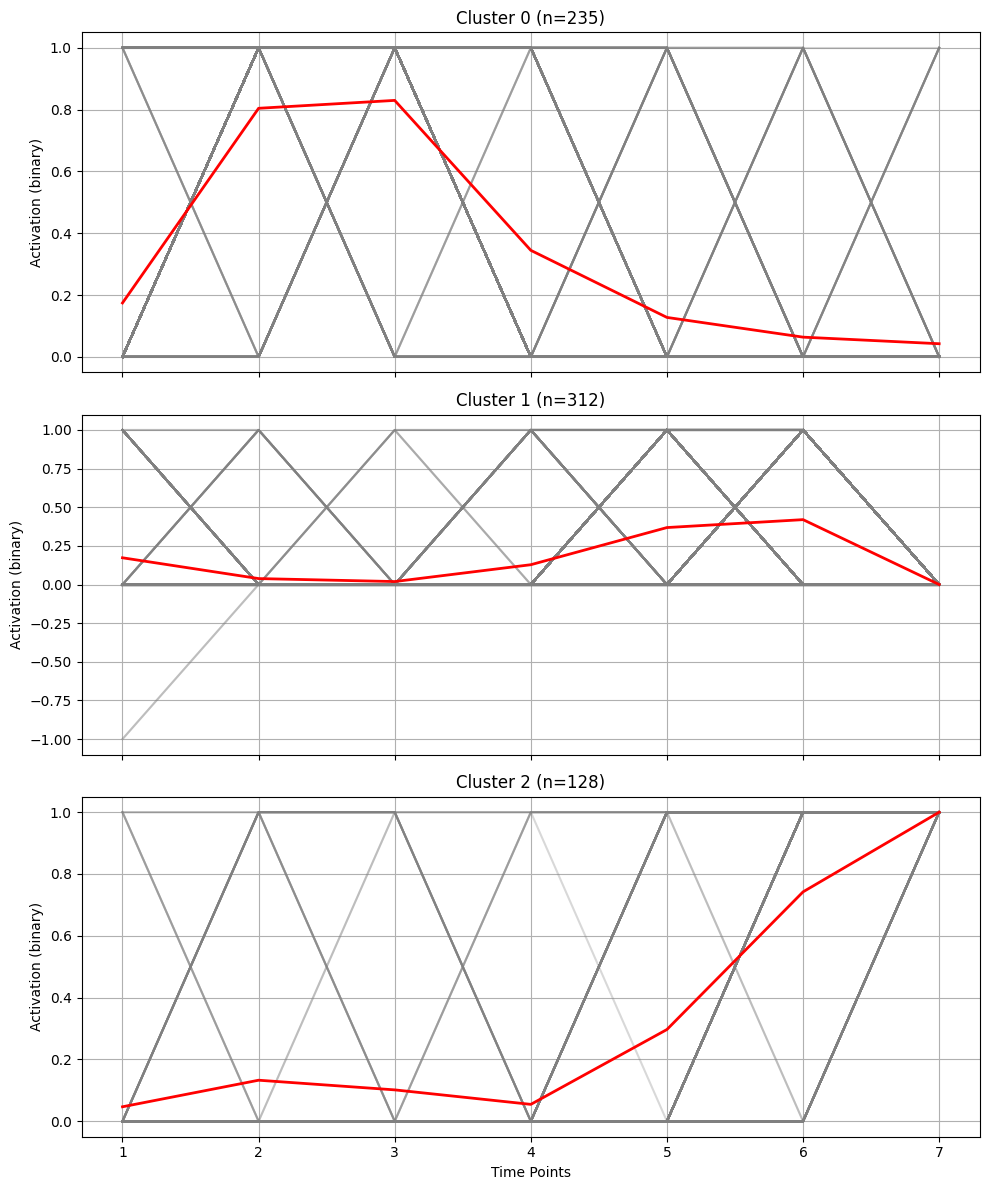

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# -------------------
# Step 1: Prepare binary feature matrix
# -------------------
# Assuming features_encoded is already defined
weight_cols = [f"weight_{i}" for i in range(1, 8)]
X = features_encoded[weight_cols].values

# -------------------
# Step 2: Standardize features (optional for binary, but helps KMeans)
# -------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------
# Step 3: Apply KMeans clustering
# -------------------
n_clusters = 3  # You can tune this
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to DataFrame
features_encoded["cluster"] = labels

# -------------------
# Step 4: Plot binary time-series per cluster
# -------------------
time_points = range(1, 8)
fig, axes = plt.subplots(n_clusters, 1, figsize=(10, 4 * n_clusters), sharex=True)

for c in range(n_clusters):
    ax = axes[c]
    cluster_data = features_encoded[features_encoded["cluster"] == c][weight_cols]
    
    # Plot each binary time-series line
    for _, row in cluster_data.iterrows():
        ax.plot(time_points, row.values, color='gray', alpha=0.3)
    
    # Plot cluster mean profile
    mean_profile = cluster_data.mean()
    ax.plot(time_points, mean_profile.values, color='red', linewidth=2)
    
    ax.set_title(f"Cluster {c} (n={cluster_data.shape[0]})")
    ax.set_ylabel("Activation (binary)")
    ax.grid(True)

axes[-1].set_xlabel("Time Points")
plt.tight_layout()
plt.show()


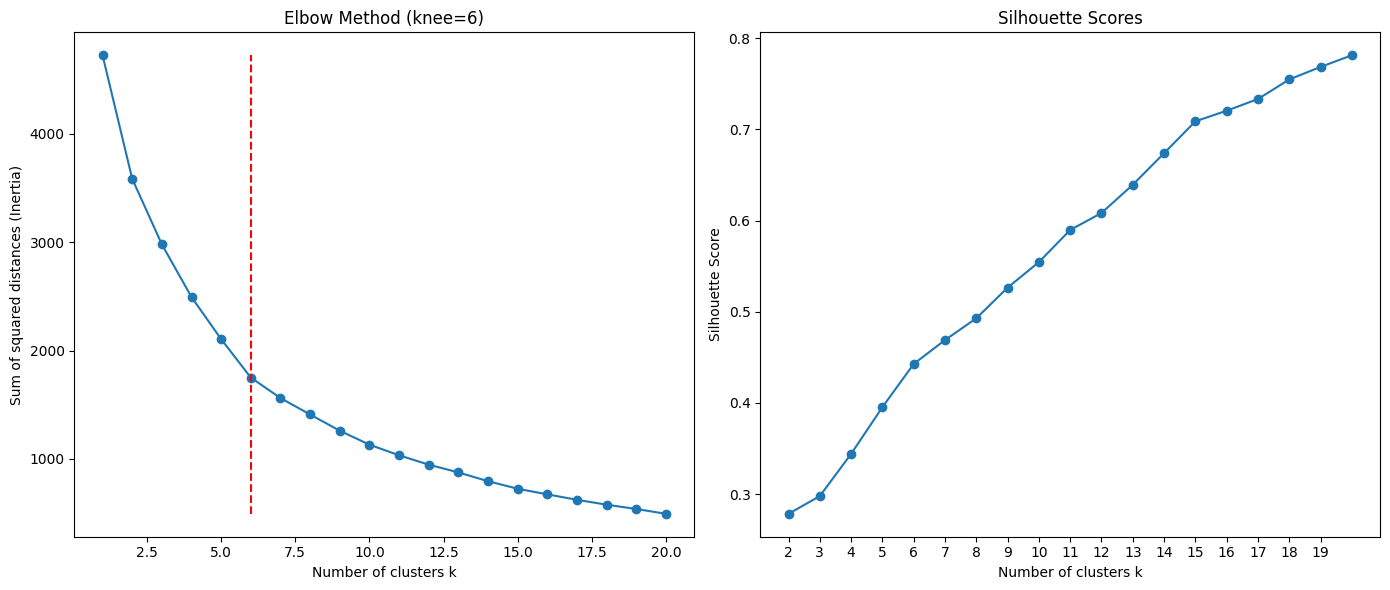

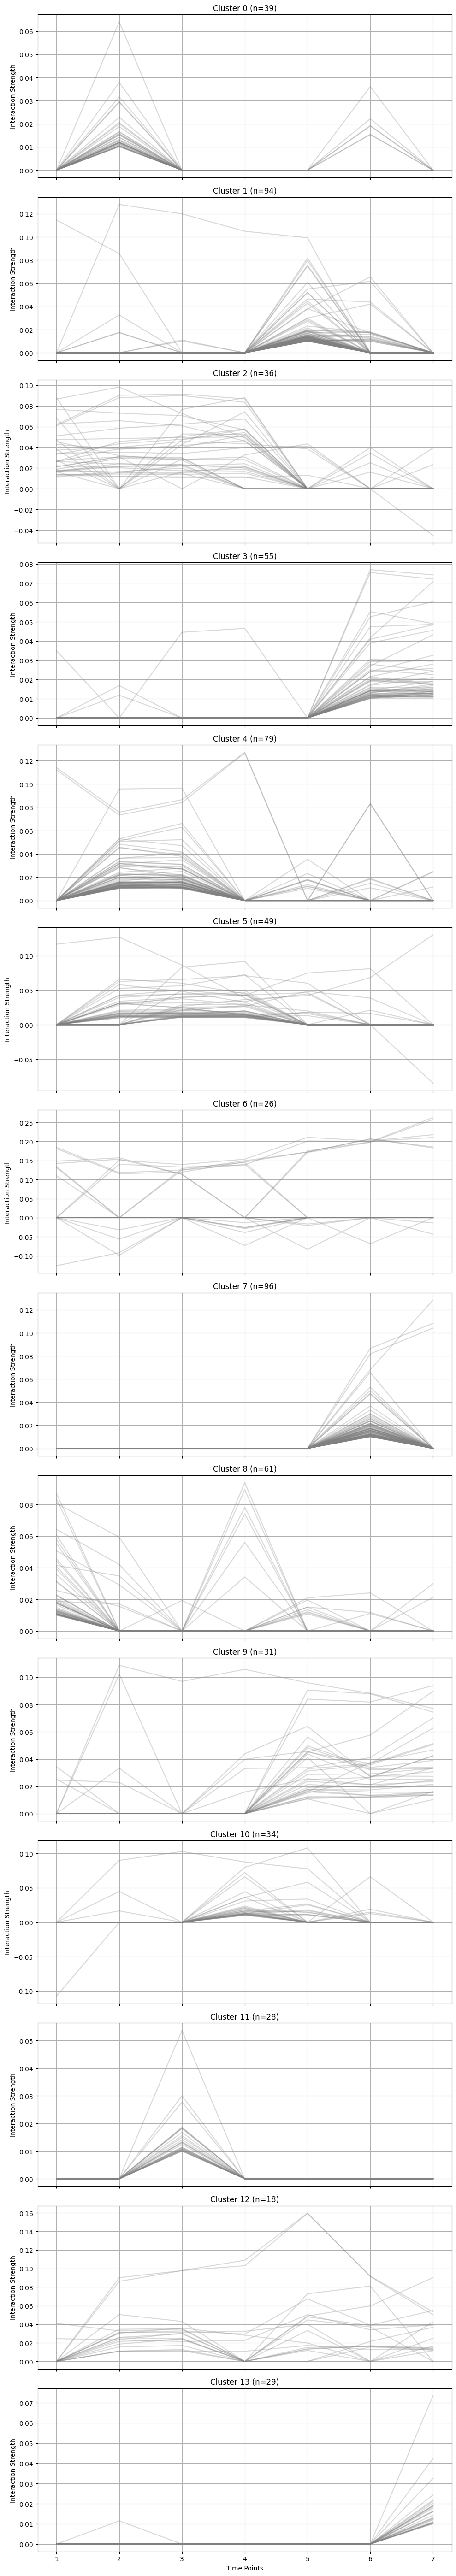

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# -------------------
# Step 1: Prepare binary feature matrix
# -------------------
weight_cols = [f"weight_{i}" for i in range(1, 8)]
X_bin = features_encoded[weight_cols].values

# -------------------
# Step 2: Standardize binary features
# -------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_bin)

# elbow method
sse = []
k_range = range(1, 21)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=100)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)
knee = KneeLocator(k_range, sse, curve='convex', direction='decreasing')
# silhouette scores
silhouette_scores = []
for k in range(2, 21):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=100)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
# plot both side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Elbow plot
axes[0].plot(k_range, sse, marker='o')
if knee.knee is not None:
    axes[0].vlines(knee.knee, ymin=min(sse), ymax=max(sse), colors='r', linestyles='dashed')
    axes[0].set_title(f'Elbow Method (knee={knee.knee})')
else:
    axes[0].set_title("Elbow Method (no clear knee)")
axes[0].set_xlabel('Number of clusters k')
axes[0].set_ylabel('Sum of squared distances (Inertia)')
# Silhouette plot
axes[1].plot(range(2, 21), silhouette_scores, marker='o')
axes[1].set_title("Silhouette Scores")
axes[1].set_xlabel('Number of clusters k')

axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(range(2, 20))
plt.tight_layout()
plt.show()

# -------------------
# Step 3: Apply KMeans clustering
# -------------------
n_clusters = 14  # You can adjust this
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to binary DataFrame
features_encoded["cluster"] = labels
#df["cluster"] = labels
# -------------------
# Step 4: Plot actual interaction strength from original df
# -------------------
time_points = range(1, 8)
fig, axes = plt.subplots(n_clusters, 1, figsize=(10, 4 * n_clusters), sharex=True)

for c in range(n_clusters):
    ax = axes[c]
    
    # Get indices of rows in this cluster
    cluster_indices = features_encoded[features_encoded["cluster"] == c].index
    
    # Pull actual data from original df
    cluster_data = df.loc[cluster_indices, weight_cols]
    
    # Plot individual time-series lines
    for _, row in cluster_data.iterrows():
        ax.plot(time_points, row.values, color='gray', alpha=0.3)
    
    # Plot cluster mean profile
    mean_profile = cluster_data.mean()
    #ax.plot(time_points, mean_profile.values, color='red', linewidth=2)
    
    ax.set_title(f"Cluster {c} (n={cluster_data.shape[0]})")
    ax.set_ylabel("Interaction Strength")
    ax.grid(True)

axes[-1].set_xlabel("Time Points")
plt.tight_layout()
plt.show()
# add clusters to df





In [43]:
df.drop(columns='cluster', inplace=True, errors='ignore')
df.drop(columns='std', inplace=True, errors='ignore')

In [44]:
# load interactions from cluster 0 with their actual weights
cluster_0_indices = features_encoded[features_encoded["cluster"] == 0].index
cluster_0_data = df.loc[cluster_0_indices, weight_cols]
cluster_0_data.head(20)

,weight_1,weight_2,weight_3,weight_4,weight_5,weight_6,weight_7
Reg,,,,,,,
snR18_YNL300W,0.0,0.011987,0.0,0.0,0.0,0.000000,0.0
snR18_snR31,0.0,0.010656,0.0,0.0,0.0,0.000000,0.0
snR18_YPL047W,0.0,0.011194,0.0,0.0,0.0,0.000000,0.0
snR18_snR58,0.0,0.029642,0.0,0.0,0.0,0.000000,0.0
snR18_YNL015W,0.0,0.011986,0.0,0.0,0.0,0.022181,0.0
snR18_YLR230W,0.0,0.015139,0.0,0.0,0.0,0.000000,0.0
snR18_snR46,0.0,0.014181,0.0,0.0,0.0,0.000000,0.0
snR18_YGR183C,0.0,0.016641,0.0,0.0,0.0,0.000000,0.0
snR18_YJR048W,0.0,0.010470,0.0,0.0,0.0,0.000000,0.0


In [45]:
df= pd.read_csv("input_data/Yeast_consolidated_gene_regulation_network.csv")

# remove duplicate rows
df = df.drop_duplicates()
df.shape
# replace values with 0 if lower than 0.01
df[df.iloc[:,1:].abs() < 0.01] = 0
df.set_index('Reg', inplace=True)
df.head(20)

,weight_1,weight_2,weight_3,weight_4,weight_5,weight_6,weight_7
Reg,,,,,,,
YPR182W_YOL039W,0.010540,0.0,0.0,0.000000,0.0108,0.0,0.000000
snR77_YBR252W,0.010698,0.0,0.0,0.000000,0.0000,0.0,0.000000
snR77_YLR062C,0.011013,0.0,0.0,0.000000,0.0000,0.0,0.000000
snR77_YGR063C,0.012532,0.0,0.0,0.000000,0.0000,0.0,0.000000
snR77_YLR402W,0.040704,0.0,0.0,0.000000,0.0000,0.0,0.029929
snR77_YDL061C,0.038971,0.0,0.0,0.073967,0.0000,0.0,0.000000
snR77_YML129C,0.045761,0.0,0.0,0.089311,0.0000,0.0,0.000000
snR77_YDR276C,0.035709,0.0,0.0,0.056059,0.0000,0.0,0.000000
snR77_YPL136W,0.013388,0.0,0.0,0.000000,0.0000,0.0,0.000000


In [46]:

# Constant rows: std == 0
constant_mask = df[weight_cols].std(axis=1) == 0
df_constant = df[constant_mask].copy()  # all constant rows
df_active = df[~constant_mask].copy()   # only variable rows

print(f"Constant rows: {df_constant.shape[0]}, Active rows: {df_active.shape[0]}")

# Use only active rows for encoding
X_active = df_active[weight_cols].values


# encode coefficients:
# 1 if 0 < val < 0.1
# 0 otherwise
def encode_coefficients(row):
    encoded = []
    for val in row:
        if 0 < val < 0.1:
            encoded.append(1)
        elif val <= -0.1:
            encoded.append(-1)
        else:
            encoded.append(0)
    return encoded

features_encoded = np.array([encode_coefficients(row) for row in X_active])
features_encoded = pd.DataFrame(features_encoded, index=df_active.index, columns=weight_cols)


Constant rows: 0, Active rows: 675


# Final clustering method

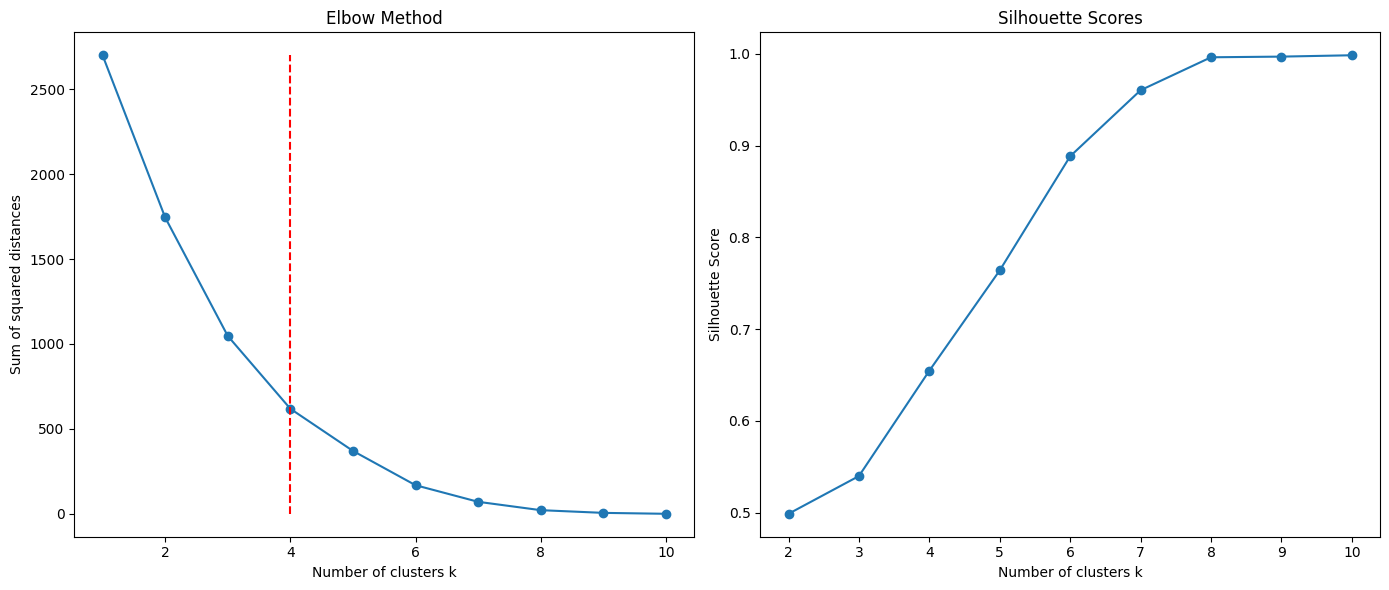

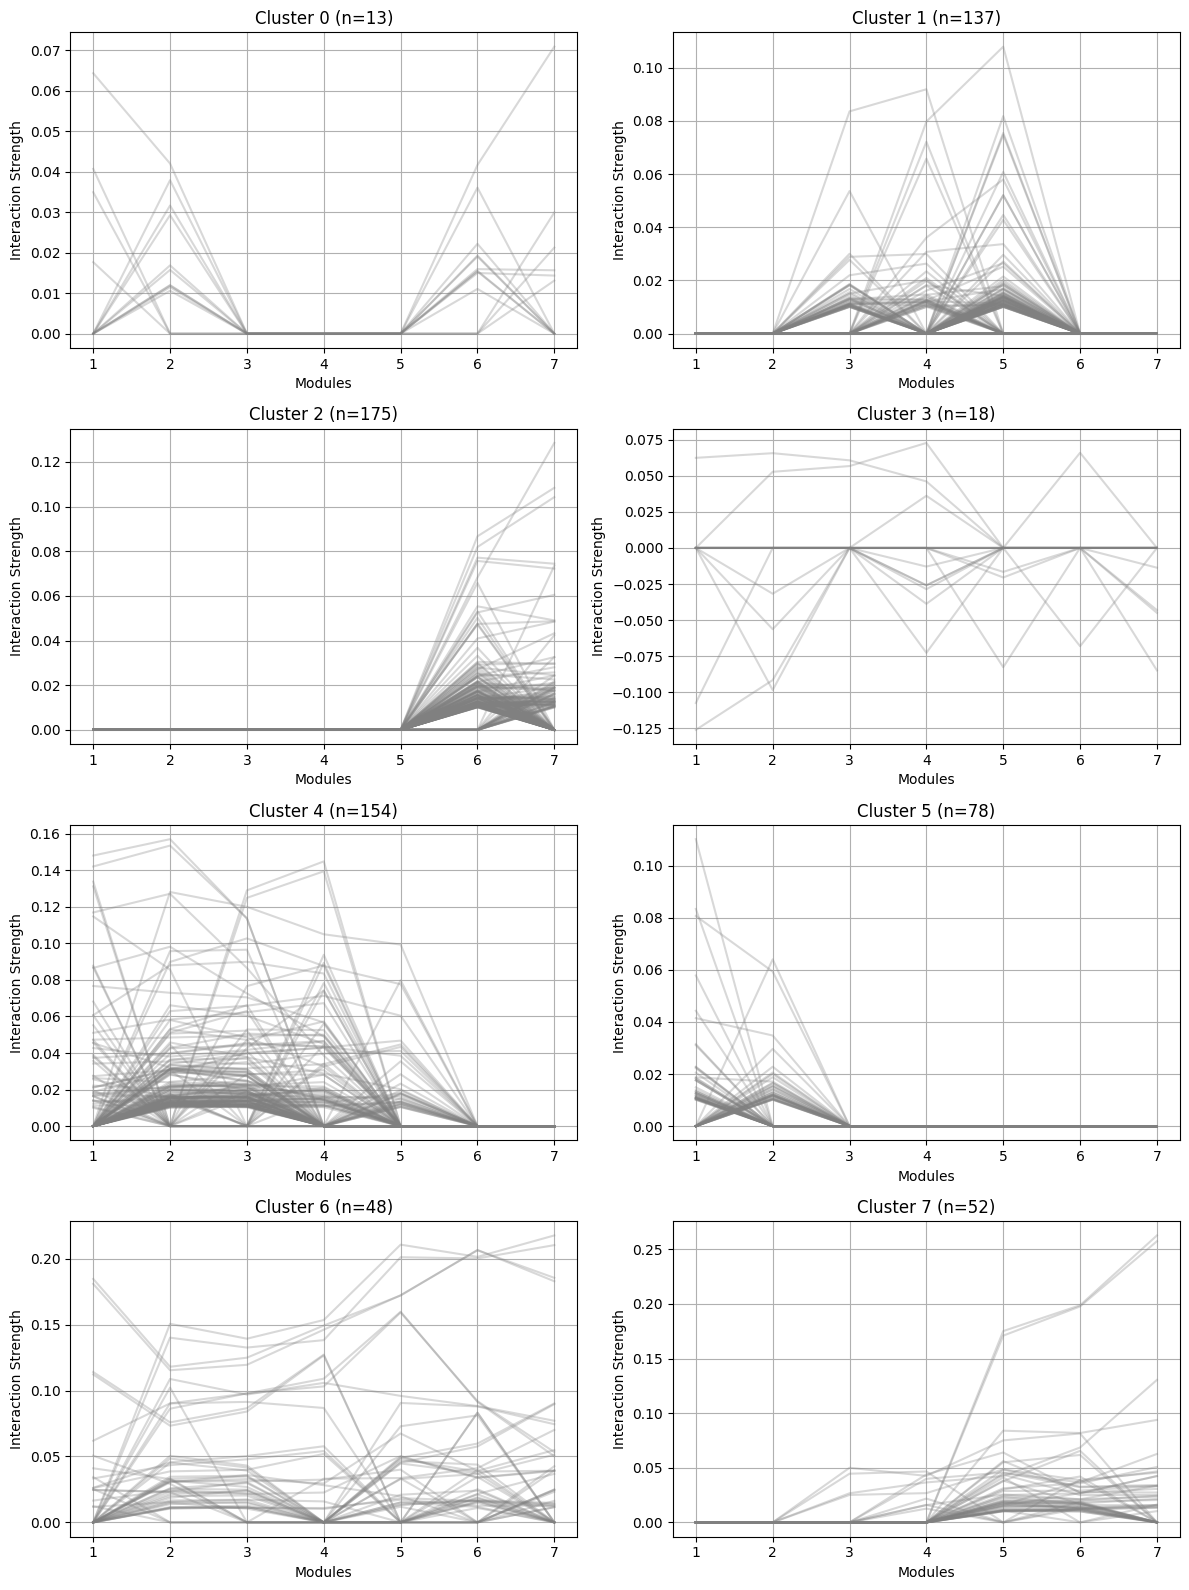

Silhouette Score for k=8: 0.9963
Silhouette (original): 0.9538


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

# -------------------
# Step 1: Collapse features into early/mid/late peaks
# -------------------
features_encoded = pd.DataFrame(index=df.index)

features_encoded["peak_early"] = (df[["weight_1", "weight_2"]].max(axis=1) > 0).astype(int)
features_encoded["peak_mid"]   = (df[["weight_3", "weight_4", "weight_5"]].max(axis=1) > 0).astype(int)
features_encoded["peak_late"]  = (df[["weight_6", "weight_7"]].max(axis=1) > 0).astype(int)

# Negative peaks (new)
features_encoded["peak_neg"] = (df[["weight_1", "weight_2", "weight_3", "weight_4", "weight_5", "weight_6", "weight_7"]].min(axis=1) < 0).astype(int)
#features_encoded["peak_late_neg"]  = (df[["weight_5", "weight_6", "weight_7"]].min(axis=1) < 0).astype(int)
# -------------------
# Step 2: Standardize features
# -------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_encoded)

# -------------------
# Step 3: Elbow and silhouette method
# -------------------
sse = []
k_range = range(1, 11)  # fewer since only 3 features
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=100)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)
knee = KneeLocator(k_range, sse, curve='convex', direction='decreasing')

silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=100)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].plot(k_range, sse, marker='o')
if knee.knee is not None:
    axes[0].vlines(knee.knee, ymin=min(sse), ymax=max(sse), colors='r', linestyles='dashed')
    axes[0].set_title(f'Elbow Method')
else:
    axes[0].set_title("Elbow Method")
axes[0].set_xlabel('Number of clusters k')
axes[0].set_ylabel('Sum of squared distances')

axes[1].plot(range(2, 11), silhouette_scores, marker='o')
axes[1].set_title("Silhouette Scores")
axes[1].set_xlabel('Number of clusters k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(range(2, 11))
plt.tight_layout()
plt.show()

# -------------------
# Step 4: Apply KMeans clustering
# -------------------
#n_clusters = knee.knee if knee.knee is not None else 3
n_clusters = 8
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=100)
labels = kmeans.fit_predict(X_scaled)

features_encoded["cluster"] = labels

# -------------------
# Step 5: Plot actual interaction strength from original df
# -------------------
time_points = range(1, 8)
cols = 2
rows = int(np.ceil(n_clusters / cols))
plt.figure(figsize=(cols*6, rows*4))

for c in range(n_clusters):
    ax = plt.subplot(rows, cols, c+1)
    cluster_indices = features_encoded[features_encoded["cluster"] == c].index
    cluster_data = df.loc[cluster_indices, [f"weight_{i}" for i in range(1, 8)]]
    
    for _, row in cluster_data.iterrows():
        ax.plot(time_points, row.values, color='gray', alpha=0.3)
    
    mean_profile = cluster_data.mean()
    #ax.plot(time_points, mean_profile.values, color='red', linewidth=2)
    
    ax.set_title(f"Cluster {c} (n={cluster_data.shape[0]})")
    ax.set_xlabel("Modules")
    ax.set_ylabel("Interaction Strength")
    ax.grid(True)

plt.tight_layout()
plt.show()
# add clusters to df
df["cluster"] = features_encoded["cluster"]
# export to csv
df.to_csv("Yeast_gene_reg_clusters.csv")
# print sillhoute score
score = silhouette_score(X_scaled, labels)
print(f'Silhouette Score for k={n_clusters}: {score:.4f}')

# silhouette in original data space (optional validation)
sil_score_original = silhouette_score(df.values, labels)
print(f"Silhouette (original): {sil_score_original:.4f}")

